# EDA integrado orientado al target

Este notebook usa la tabla integrada para analizar la relacion entre caracteristicas de cliente/oferta/canal y el resultado de la campania.

No se hace modelado todavia. El objetivo es entender patrones, relacion con target, pruebas simples y foco Movistar Total.

In [1]:
# Importar librerias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import chi2_contingency, mannwhitneyu, ttest_ind, probplot

pd.set_option("display.max_columns", 160)
pd.set_option("display.max_rows", 120)
sns.set_theme(style="whitegrid")

## 1. Carga de datos y construccion de tabla integrada

In [2]:
# Cargar datos
clientes = pd.read_csv("../data/dataset_clientes.csv")
catalogo = pd.read_csv("../data/catalogo_ofertas_entrega.csv")
campanias = pd.read_csv("../data/historial_campanias.csv")

In [3]:
# Estandarizar texto a minusculas y quitar espacios
ids = ["cliente_id", "oferta_id", "ofrecimiento_id", "oferta_hogar_id", "plan_actual_id"]

for df in [clientes, catalogo, campanias]:
    for col in df.select_dtypes(include="object").columns:
        if col not in ids:
            df[col] = df[col].str.strip().str.lower()

In [4]:
# Recodificar nulos estructurales en clientes
clientes.loc[clientes["oferta_hogar_id"].isna() & (clientes["tiene_hogar"] == False), "oferta_hogar_id"] = "sin_servicio_hogar"
clientes.loc[clientes["tipo_cliente"].isna() & (clientes["tiene_movil"] == False), "tipo_cliente"] = "sin_movil"
clientes.loc[clientes["canal_mas_usado"].isna() & (clientes["n_actividad_canal"] == 0), "canal_mas_usado"] = "sin_actividad"

In [5]:
# Recodificar nulos estructurales en campanias y catalogo
campanias.loc[campanias["motivo_rechazo"].isna() & (campanias["resultado"] != "rechazada"), "motivo_rechazo"] = "no_aplica"

clientes_movil = clientes[["cliente_id", "tiene_movil"]]
camp_check = campanias[["cliente_id", "tipo_cliente"]].merge(clientes_movil, on="cliente_id", how="left")
campanias.loc[campanias["tipo_cliente"].isna() & (camp_check["tiene_movil"] == False), "tipo_cliente"] = "sin_movil"

catalogo.loc[catalogo["cluster_hogar"].isna() & (catalogo["tipo_oferta"] != "plan_hogar"), "cluster_hogar"] = "no_aplica"
catalogo.loc[catalogo["descripcion_bundle"].isna() & (catalogo["tipo_oferta"] != "plan_hogar"), "descripcion_bundle"] = "no_aplica"

In [6]:
# Construir tabla integrada usando campanias como base
filas_base = len(campanias)

analitica = campanias.merge(clientes, on="cliente_id", how="left", suffixes=("_camp", "_cli"))

for col in ["tipo_cliente", "antiguedad_meses", "elegible_mt", "es_movistar_total"]:
    analitica[col] = analitica[f"{col}_cli"]
    analitica = analitica.drop(columns=[f"{col}_camp", f"{col}_cli"])

catalogo_join = catalogo.rename(columns={"es_movistar_total": "oferta_catalogo_es_mt"})
analitica = analitica.merge(catalogo_join, on="oferta_id", how="left", suffixes=("_camp", "_cat"))

for col in ["nombre_oferta", "tipo_oferta"]:
    analitica[col] = analitica[f"{col}_cat"]
    analitica = analitica.drop(columns=[f"{col}_camp", f"{col}_cat"])

In [7]:
# Validar tabla integrada
pd.DataFrame({
    "filas_base_campanias": [filas_base],
    "filas_analitica": [len(analitica)],
    "columnas_analitica": [analitica.shape[1]],
    "ofrecimiento_id_unicos": [analitica["ofrecimiento_id"].nunique()],
    "duplicados_ofrecimiento_id": [analitica["ofrecimiento_id"].duplicated().sum()],
    "mantiene_filas_base": [len(analitica) == filas_base]
})

,filas_base_campanias,filas_analitica,columnas_analitica,ofrecimiento_id_unicos,duplicados_ofrecimiento_id,mantiene_filas_base
0,300112,300112,44,300112,0,True


**Hallazgo:** la tabla `analitica` mantiene la unidad de analisis de campanias: una fila por ofrecimiento. Esta tabla permite cruzar cliente, oferta, canal y resultado.

## 2. Definicion del target de aceptacion

Para analizar aceptacion se excluye `pendiente`, porque no representa una negativa clara del cliente.

- aceptada = 1
- rechazada = 0
- pendiente se analiza aparte

In [8]:
# Crear target binario solo para aceptada y rechazada
analitica["target_aceptacion"] = np.nan
analitica.loc[analitica["resultado"] == "aceptada", "target_aceptacion"] = 1
analitica.loc[analitica["resultado"] == "rechazada", "target_aceptacion"] = 0

base_target = analitica[analitica["target_aceptacion"].notna()].copy()
base_target["target_aceptacion"] = base_target["target_aceptacion"].astype(int)

In [9]:
# Distribucion del resultado original
analitica["resultado"].value_counts(dropna=False).to_frame("ofrecimientos").assign(
    porcentaje=lambda x: (x["ofrecimientos"] / len(analitica) * 100).round(2)
)

,ofrecimientos,porcentaje
resultado,,
rechazada,159204,53.05
aceptada,95414,31.79
pendiente,45494,15.16


In [10]:
# Tasa de aceptacion general en base con resultado cerrado
tasa_general = base_target["target_aceptacion"].mean() * 100
pd.DataFrame({
    "ofrecimientos_cerrados": [len(base_target)],
    "aceptadas": [base_target["target_aceptacion"].sum()],
    "rechazadas": [(base_target["target_aceptacion"] == 0).sum()],
    "tasa_aceptacion_pct": [round(tasa_general, 2)]
})

,ofrecimientos_cerrados,aceptadas,rechazadas,tasa_aceptacion_pct
0,254618,95414,159204,37.47


**Hallazgo target:** la tasa general es la referencia base. Cualquier segmento debe compararse contra esta tasa para evaluar si realmente destaca.

### Funnel previo al target

Antes de modelar aceptacion se revisa cuantos ofrecimientos llegaron realmente a contacto.

In [11]:
# Resumir contactabilidad y resultados del funnel
funnel = pd.DataFrame({
    "etapa": ["ofrecimientos", "contactados", "aceptados", "rechazados", "no_contactados"],
    "cantidad": [
        len(analitica),
        (analitica["contactabilidad"] == "contactado").sum(),
        (analitica["resultado"] == "aceptada").sum(),
        (analitica["resultado"] == "rechazada").sum(),
        (analitica["contactabilidad"] == "no_contactado").sum()
    ]
})
funnel["porcentaje_total"] = (funnel["cantidad"] / len(analitica) * 100).round(2)
funnel

,etapa,cantidad,porcentaje_total
0,ofrecimientos,300112,100.00
1,contactados,254618,84.84
2,aceptados,95414,31.79
3,rechazados,159204,53.05
4,no_contactados,45494,15.16


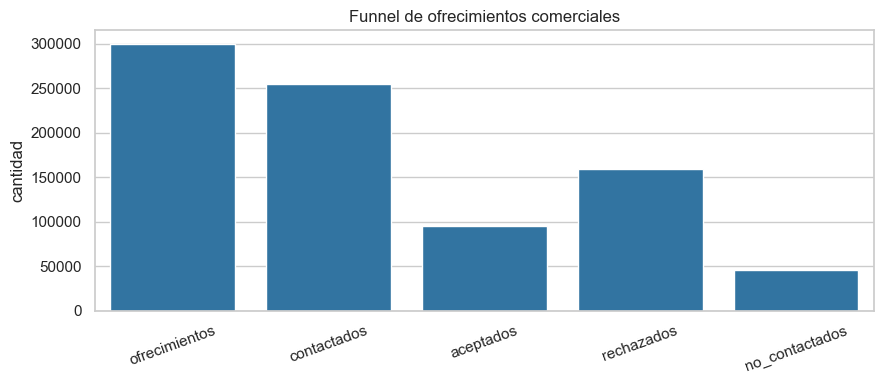

In [12]:
# Graficar el funnel comercial observado
plt.figure(figsize=(9, 4))
sns.barplot(data=funnel, x="etapa", y="cantidad", color="#1f77b4")
plt.title("Funnel de ofrecimientos comerciales")
plt.xlabel("")
plt.ylabel("cantidad")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

**Hallazgo de negocio:** el 84.84% de los ofrecimientos llego a contacto y el 15.16% quedo pendiente por falta de contacto. La tasa de aceptacion es 37.47% entre contactados, pero la conversion sobre todos los intentos es 31.79%. La solucion puede mejorar ventas tanto priorizando clientes contactables como estimando aceptacion entre quienes si fueron contactados.

### Graficos del target

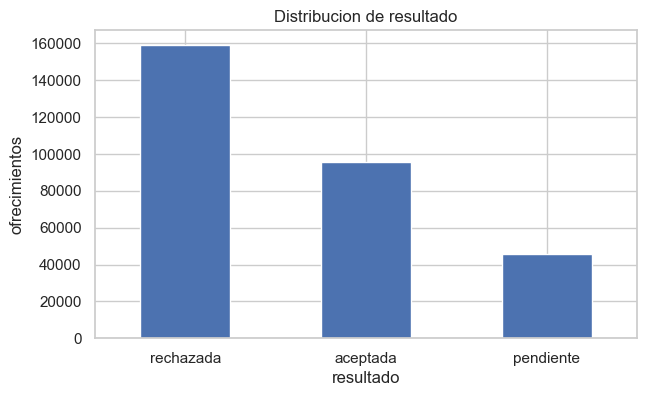

In [13]:
# Graficar distribucion de resultado original
plt.figure(figsize=(7, 4))
analitica["resultado"].value_counts().plot(kind="bar")
plt.title("Distribucion de resultado")
plt.xlabel("resultado")
plt.ylabel("ofrecimientos")
plt.xticks(rotation=0)
plt.show()

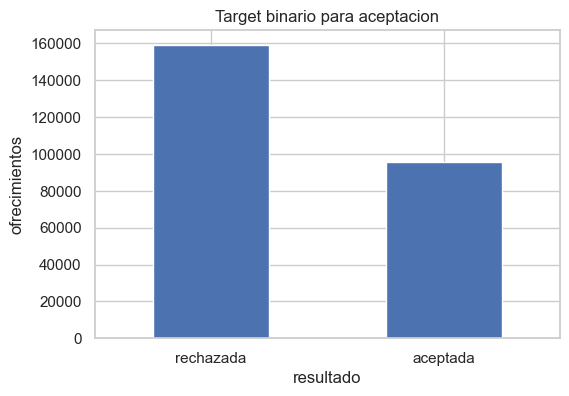

In [14]:
# Graficar target binario sin pendientes
plt.figure(figsize=(6, 4))
base_target["resultado"].value_counts().plot(kind="bar")
plt.title("Target binario para aceptacion")
plt.xlabel("resultado")
plt.ylabel("ofrecimientos")
plt.xticks(rotation=0)
plt.show()

**Hallazgo grafico:** el target tiene mas rechazos que aceptaciones. `pendiente` queda fuera del analisis binario porque no representa rechazo real.

## 3. EDA cruzado: tasas de aceptacion por variables categoricas

In [15]:
# Funcion simple para calcular tasa de aceptacion por categoria
# Se usa solo para no repetir el mismo groupby muchas veces
def tasa_por_categoria(df, col, min_n=100):
    tabla = df.groupby(col, dropna=False).agg(
        ofrecimientos=("target_aceptacion", "size"),
        aceptadas=("target_aceptacion", "sum")
    ).reset_index()
    tabla["tasa_aceptacion_pct"] = (tabla["aceptadas"] / tabla["ofrecimientos"] * 100).round(2)
    tabla = tabla[tabla["ofrecimientos"] >= min_n]
    return tabla.sort_values("tasa_aceptacion_pct", ascending=False)

In [16]:
# Tasa por tipo de cliente
acc_tipo_cliente = tasa_por_categoria(base_target, "tipo_cliente")
acc_tipo_cliente

,tipo_cliente,ofrecimientos,aceptadas,tasa_aceptacion_pct
0,postpago,142251,57145,40.17
1,prepago,95245,32502,34.12
2,sin_movil,17122,5767,33.68


**Hallazgo:** `tipo_cliente` permite comparar segmentos comerciales basicos. Diferencias de tasa pueden orientar segmentacion, pero aun no implican causalidad.

In [17]:
# Tasa por edad
acc_edad = tasa_por_categoria(base_target, "edad_rango")
acc_edad

,edad_rango,ofrecimientos,aceptadas,tasa_aceptacion_pct
1,26-35,71340,26902,37.71
4,56-65,25788,9697,37.60
3,46-55,45505,17078,37.53
2,36-45,61329,22947,37.42
0,18-25,38058,14133,37.14
5,65+,12598,4657,36.97


In [18]:
# Tasa por uso de app
acc_app = tasa_por_categoria(base_target, "es_usuario_app")
acc_app

,es_usuario_app,ofrecimientos,aceptadas,tasa_aceptacion_pct
0,False,63751,23960,37.58
1,True,190867,71454,37.44


In [19]:
# Tasa por canal
acc_canal = tasa_por_categoria(base_target, "canal")
acc_canal

,canal,ofrecimientos,aceptadas,tasa_aceptacion_pct
3,tienda,76467,28775,37.63
2,digital,88744,33235,37.45
1,call out,38390,14375,37.44
0,call in,51017,19029,37.30


In [20]:
# Tasa por tipo de oferta
acc_tipo_oferta = tasa_por_categoria(base_target, "tipo_oferta")
acc_tipo_oferta

,tipo_oferta,ofrecimientos,aceptadas,tasa_aceptacion_pct
1,movistar_total,24207,16872,69.70
4,plan_movil,48375,16575,34.26
0,equipo,36344,12448,34.25
5,upgrade,36642,12549,34.25
3,plan_hogar,72956,24781,33.97
2,paquete_adicional,36094,12189,33.77


In [21]:
# Tasa por oferta especifica
acc_nombre_oferta = tasa_por_categoria(base_target, "nombre_oferta")
acc_nombre_oferta.head(15)

,nombre_oferta,ofrecimientos,aceptadas,tasa_aceptacion_pct
9,movistar total plus,8104,5687,70.18
7,movistar total basico,8022,5584,69.61
8,movistar total max,8081,5601,69.31
3,internet + tv + fijo hogar,12135,4217,34.75
17,router wifi 6,12116,4198,34.65
14,plan movil ilimitado,11918,4118,34.55
15,plan movil max 50gb,12095,4179,34.55
0,equipo smartphone gama alta,12129,4188,34.53
20,upgrade a plan plus,12061,4158,34.47
13,plan movil basico 10gb,12322,4242,34.43


In [22]:
# Tasa por elegibilidad Movistar Total
acc_elegible = tasa_por_categoria(base_target, "elegible_mt")
acc_elegible

,elegible_mt,ofrecimientos,aceptadas,tasa_aceptacion_pct
1,True,34694,20450,58.94
0,False,219924,74964,34.09


In [23]:
# Separar elegibilidad MT y tipo de oferta presentada
elegibilidad_oferta = base_target.groupby(["elegible_mt", "oferta_es_mt"]).agg(
    ofrecimientos=("target_aceptacion", "size"),
    tasa_aceptacion_pct=("target_aceptacion", "mean")
).reset_index()
elegibilidad_oferta["tasa_aceptacion_pct"] *= 100
elegibilidad_oferta.round(2)

,elegible_mt,oferta_es_mt,ofrecimientos,tasa_aceptacion_pct
0,False,False,219924,34.09
1,True,False,10487,34.12
2,True,True,24207,69.70


**Hallazgo clave para el modelo:** `elegible_mt` no representa por si solo una mayor propension general. En ofertas no MT, elegibles y no elegibles aceptan practicamente igual (34.12% vs 34.09%). Cuando a un elegible se le ofrece MT, la aceptacion observada sube a 69.70%. Por eso `elegible_mt` debe utilizarse como regla de elegibilidad y enrutamiento al modelo MT, no como una regla universal de compra.

**Hallazgo:** estas tasas ayudan a identificar patrones iniciales de aceptacion por perfil, canal y oferta. Para negocio, importa tanto la tasa como el volumen de ofrecimientos.

### Graficos de tasas de aceptacion por categorias clave

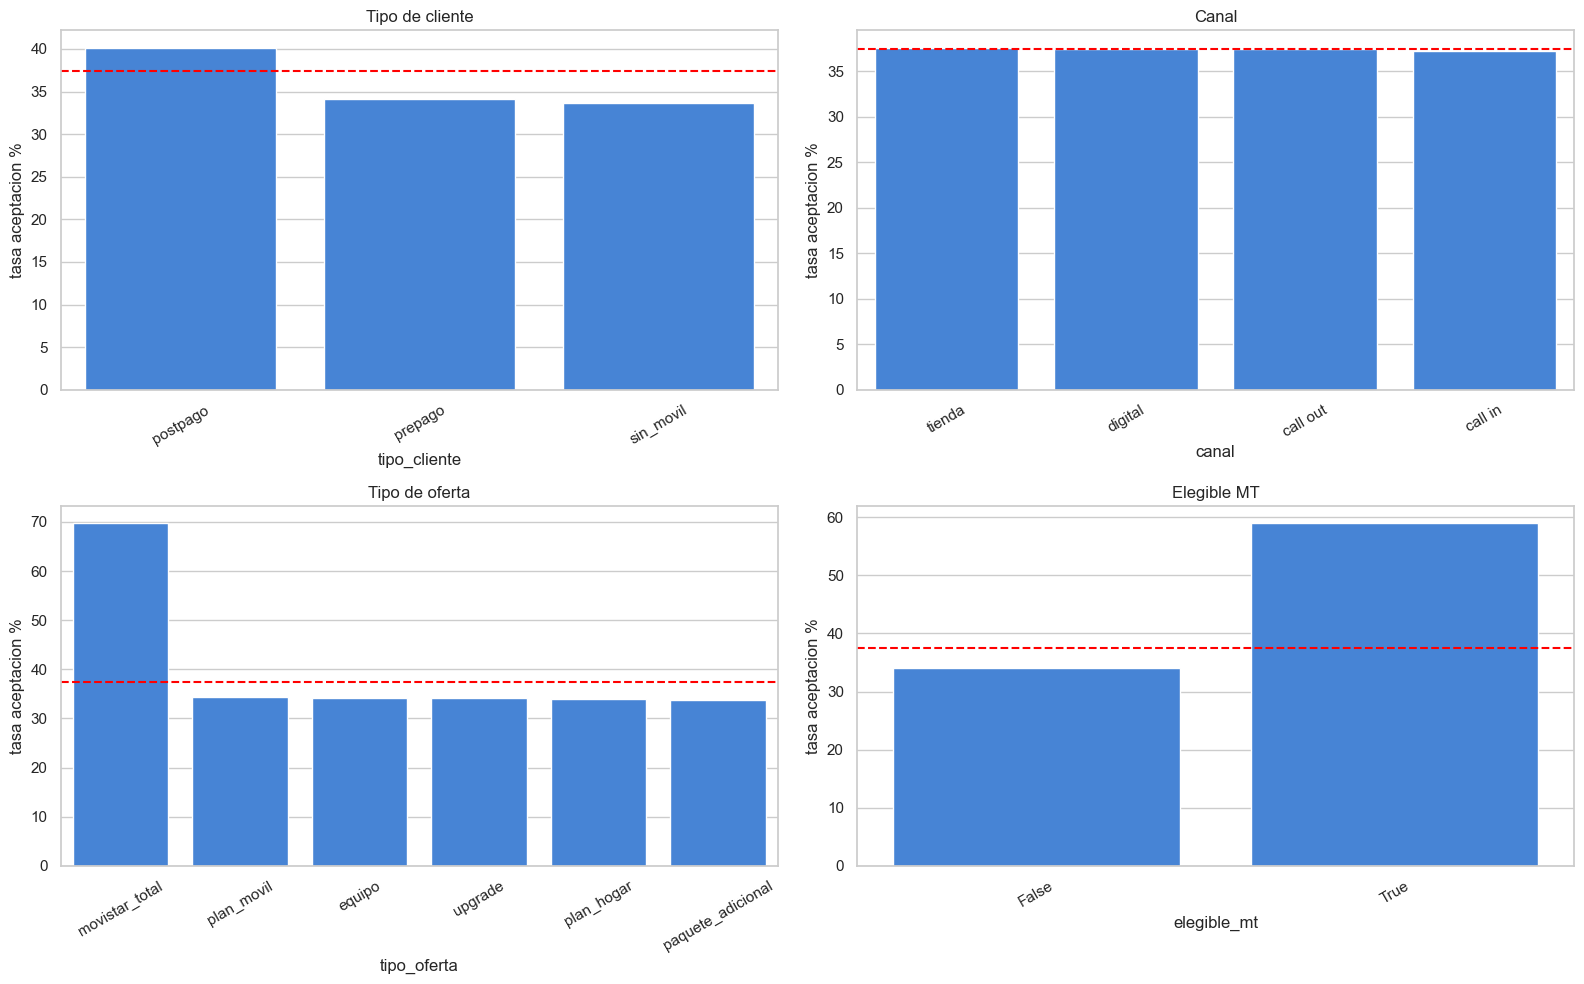

In [24]:
# Graficar tasas por variables categoricas clave
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

graficos_cat = [
    (acc_tipo_cliente, "tipo_cliente", "Tipo de cliente"),
    (acc_canal, "canal", "Canal"),
    (acc_tipo_oferta, "tipo_oferta", "Tipo de oferta"),
    (acc_elegible, "elegible_mt", "Elegible MT")
]

for ax, (tabla, col, titulo) in zip(axes.flatten(), graficos_cat):
    sns.barplot(data=tabla, x=col, y="tasa_aceptacion_pct", ax=ax, color="#2F80ED")
    ax.axhline(tasa_general, color="red", linestyle="--", label="tasa general")
    ax.set_title(titulo)
    ax.set_ylabel("tasa aceptacion %")
    ax.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

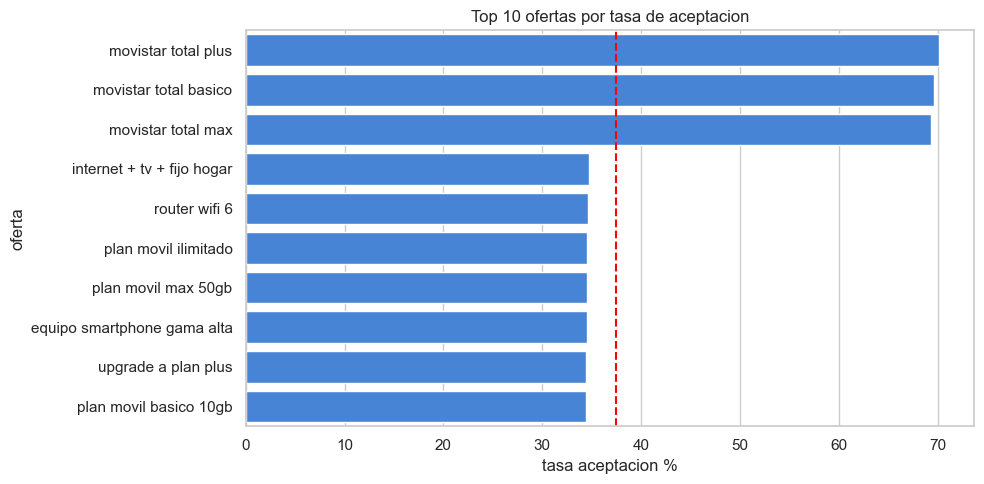

In [25]:
# Graficar top 10 ofertas por tasa de aceptacion
plt.figure(figsize=(10, 5))
top_ofertas = acc_nombre_oferta.head(10)
sns.barplot(data=top_ofertas, y="nombre_oferta", x="tasa_aceptacion_pct", color="#2F80ED")
plt.axvline(tasa_general, color="red", linestyle="--", label="tasa general")
plt.title("Top 10 ofertas por tasa de aceptacion")
plt.xlabel("tasa aceptacion %")
plt.ylabel("oferta")
plt.tight_layout()
plt.show()

**Hallazgo grafico:** las diferencias fuertes aparecen por tipo de oferta y elegibilidad MT. Canal y uso de app no parecen separar tanto la aceptacion cuando se ven solos.

## 4. Relacion entre variables numericas y target

Se comparan distribuciones y medidas entre aceptadas y rechazadas. Esto no es seleccion definitiva de variables.

In [26]:
# Variables numericas candidatas
vars_numericas = [
    "antiguedad_meses",
    "monto_facturado_prom",
    "consumo_datos_gb_prom",
    "consumo_voz_min_prom",
    "consumo_sms_prom",
    "uso_app_movistar_prom",
    "monto_facturado_prom_6m",
    "dias_mora_prom"
]

In [27]:
# Comparar media y mediana entre aceptadas y rechazadas
base_target.groupby("resultado")[vars_numericas].agg(["mean", "median"]).round(2)

antiguedad_meses        monto_facturado_prom         \
                      mean median                 mean median   
resultado                                                       
aceptada             93.29   94.0                80.52  76.06   
rechazada            88.64   88.0                81.70  76.72   

          consumo_datos_gb_prom        consumo_voz_min_prom          \
                           mean median                 mean  median   
resultado                                                             
aceptada                  29.82  23.84               180.83  180.50   
rechazada                 29.68  23.63               180.90  180.83   

          consumo_sms_prom        uso_app_movistar_prom         \
                      mean median                  mean median   
resultado                                                        
aceptada               8.0    8.0                  2.25   2.67   
rechazada              8.0    8.0                  2.25   2.67   

          monto_facturado_prom_6m        dias_mora_prom         
                             mean median           mean median  
resultado                                                       
aceptada                    80.52  76.02           7.43   6.50  
rechazada                   81.70  76.70           8.31   7.17

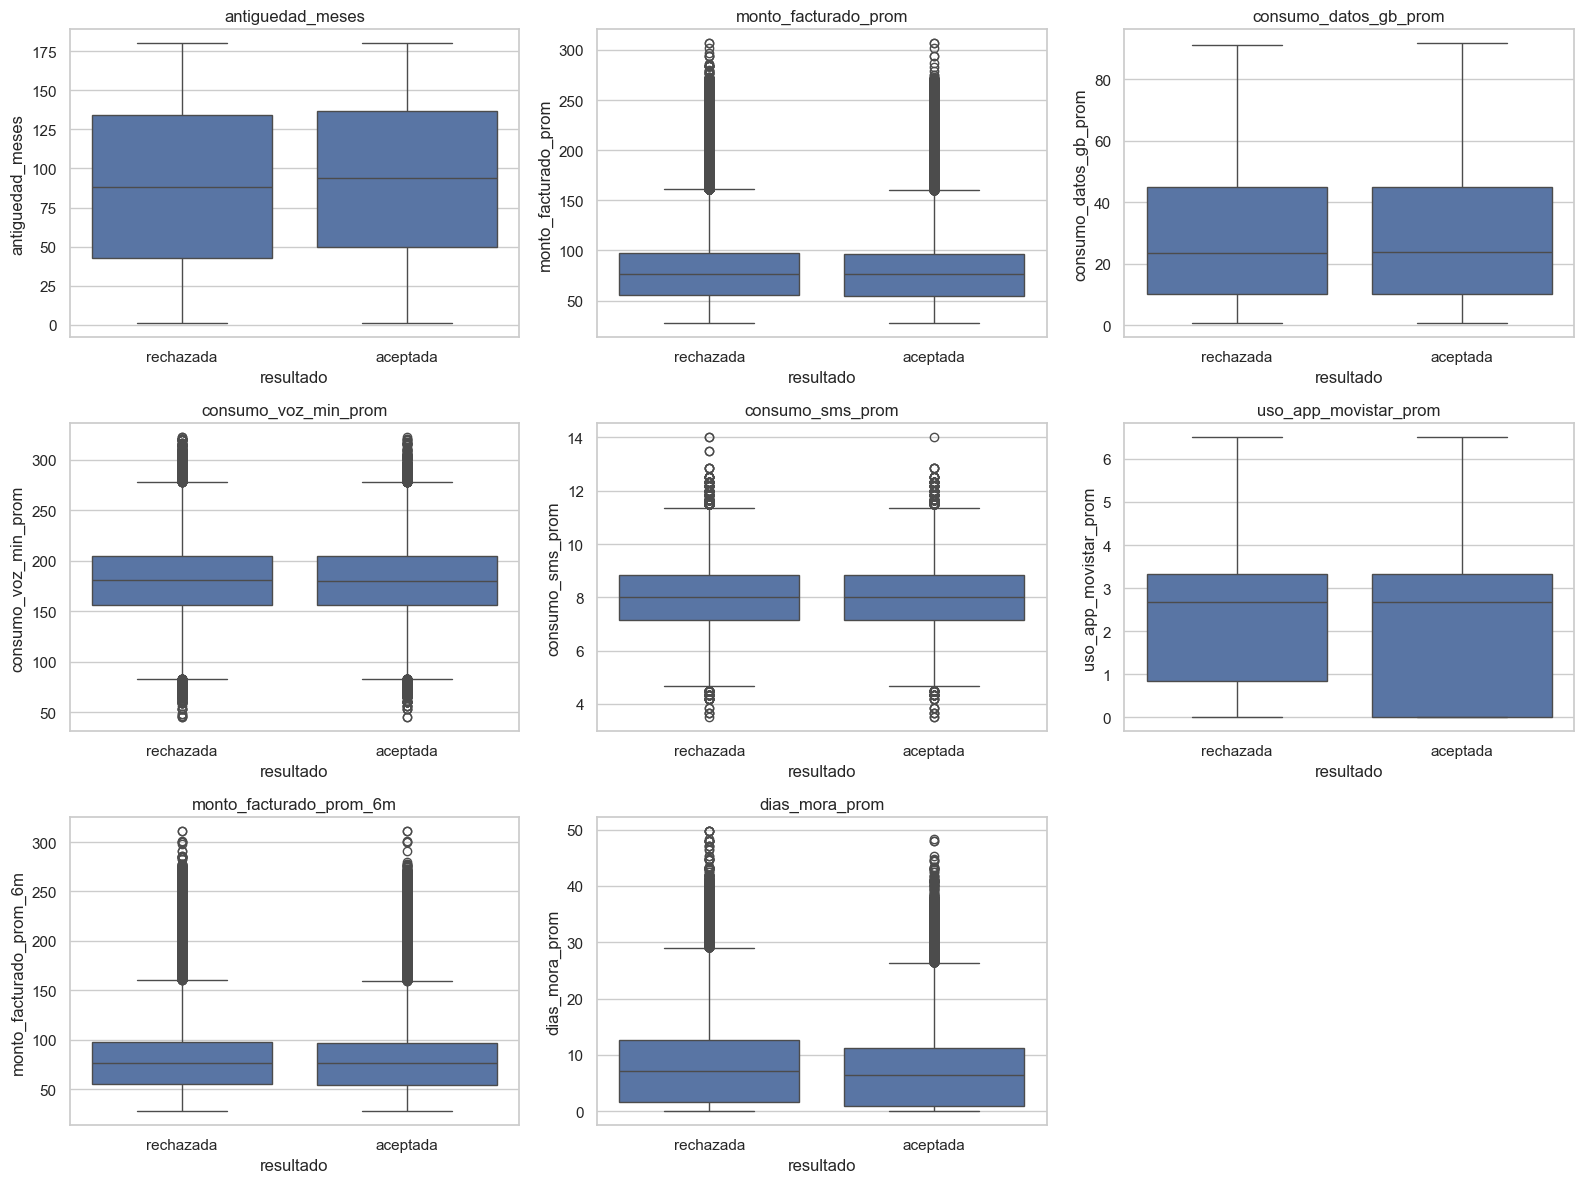

In [28]:
# Boxplots de numericas contra target
plt.figure(figsize=(16, 12))
for i, col in enumerate(vars_numericas, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(data=base_target, x="resultado", y=col)
    plt.title(col)
plt.tight_layout()
plt.show()

**Hallazgo:** comparar aceptadas y rechazadas permite observar si hay desplazamientos en facturacion, consumo, mora o antiguedad. Diferencias visibles deben evaluarse tambien por magnitud, no solo por significancia.

### Distribuciones y normalidad aproximada

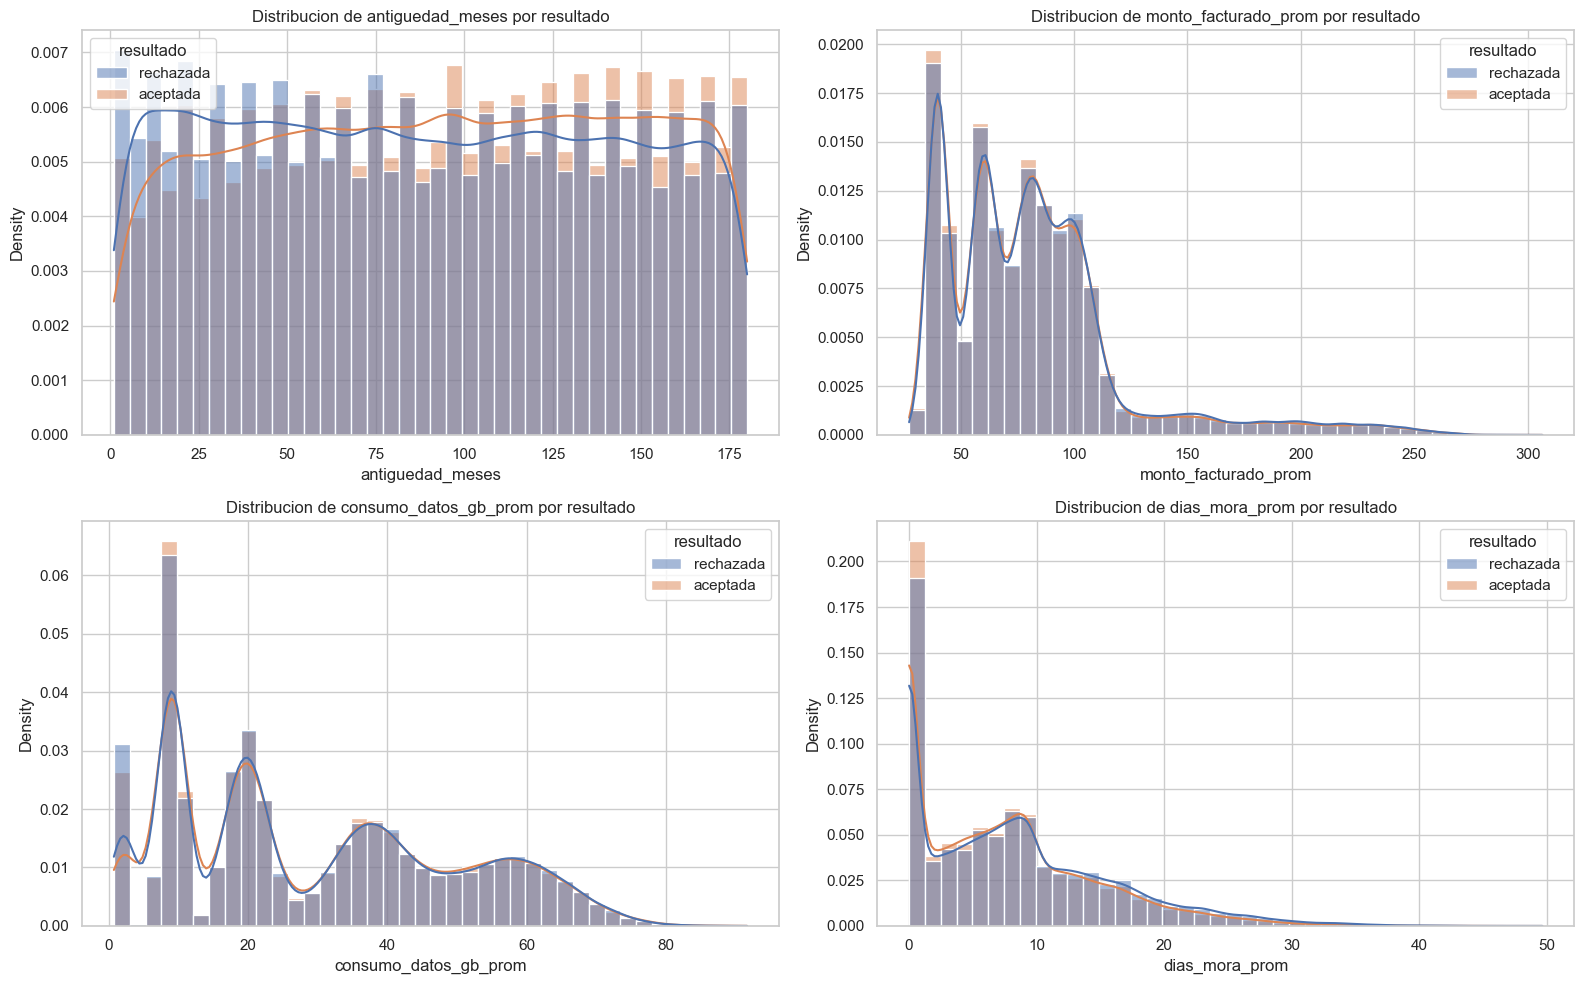

In [29]:
# Histogramas con KDE por resultado para variables numericas clave
vars_normalidad = [
    "antiguedad_meses",
    "monto_facturado_prom",
    "consumo_datos_gb_prom",
    "dias_mora_prom"
]

plt.figure(figsize=(16, 10))
for i, col in enumerate(vars_normalidad, 1):
    plt.subplot(2, 2, i)
    sns.histplot(data=base_target, x=col, hue="resultado", bins=40, kde=True, stat="density", common_norm=False)
    plt.title(f"Distribucion de {col} por resultado")
plt.tight_layout()
plt.show()

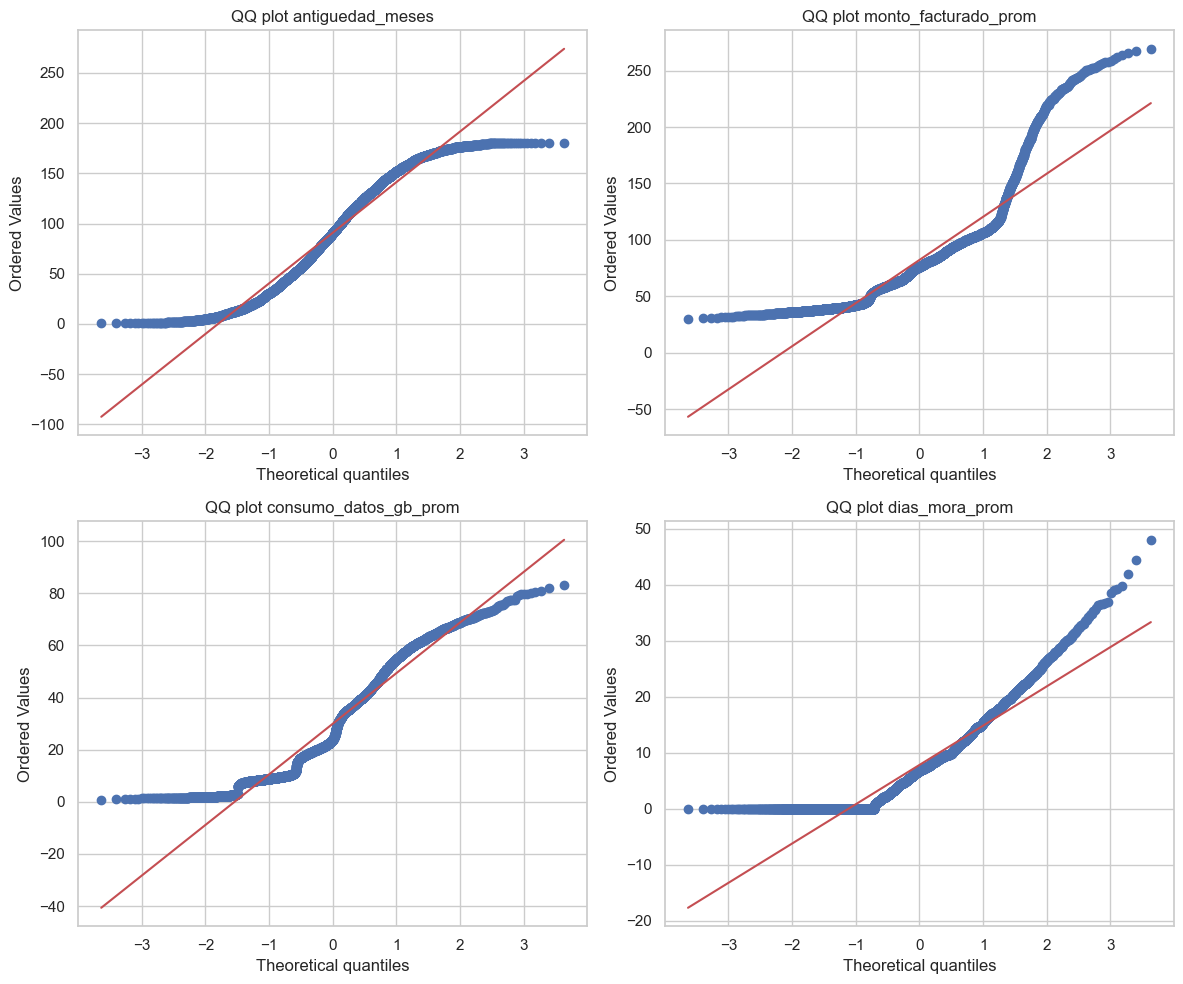

In [30]:
# QQ plots para revisar normalidad aproximada en variables numericas clave
plt.figure(figsize=(12, 10))
for i, col in enumerate(vars_normalidad, 1):
    plt.subplot(2, 2, i)
    muestra = base_target[col].dropna().sample(5000, random_state=42)
    probplot(muestra, dist="norm", plot=plt)
    plt.title(f"QQ plot {col}")
plt.tight_layout()
plt.show()

**Hallazgo normalidad:** las distribuciones no son perfectamente normales. Por eso las pruebas no parametricas como Mann-Whitney son mas prudentes que depender solo de t-test.

## 5. Segmentos descriptivos de consumo, facturacion, mora, reclamos y antiguedad

In [31]:
# Crear rangos descriptivos con cuantiles
base_target["facturacion_nivel"] = pd.qcut(base_target["monto_facturado_prom"], q=3, labels=["bajo", "medio", "alto"])
base_target["consumo_datos_nivel"] = pd.qcut(base_target["consumo_datos_gb_prom"], q=3, labels=["bajo", "medio", "alto"])
base_target["antiguedad_nivel"] = pd.qcut(base_target["antiguedad_meses"], q=3, labels=["baja", "media", "alta"])
base_target["mora_nivel"] = pd.qcut(base_target["dias_mora_prom"], q=3, labels=["baja", "media", "alta"], duplicates="drop")
base_target["reclamos_tiene"] = base_target["n_reclamos"] > 0

In [32]:
# Tasa por nivel de facturacion
acc_facturacion = tasa_por_categoria(base_target, "facturacion_nivel")
acc_facturacion

,facturacion_nivel,ofrecimientos,aceptadas,tasa_aceptacion_pct
0,bajo,84875,32351,38.12
1,medio,84873,31922,37.61
2,alto,84870,31141,36.69


In [33]:
# Tasa por nivel de consumo de datos
acc_consumo = tasa_por_categoria(base_target, "consumo_datos_nivel")
acc_consumo

,consumo_datos_nivel,ofrecimientos,aceptadas,tasa_aceptacion_pct
1,medio,84873,31971,37.67
2,alto,84872,31806,37.48
0,bajo,84873,31637,37.28


In [34]:
# Tasa por nivel de mora
acc_mora = tasa_por_categoria(base_target, "mora_nivel")
acc_mora

,mora_nivel,ofrecimientos,aceptadas,tasa_aceptacion_pct
0,baja,86407,34345,39.75
1,media,84426,32394,38.37
2,alta,83785,28675,34.22


In [35]:
# Tasa por reclamos
acc_reclamos = tasa_por_categoria(base_target, "reclamos_tiene")
acc_reclamos

,reclamos_tiene,ofrecimientos,aceptadas,tasa_aceptacion_pct
0,False,207768,79090,38.07
1,True,46850,16324,34.84


In [36]:
# Tasa por antiguedad
acc_antiguedad = tasa_por_categoria(base_target, "antiguedad_nivel")
acc_antiguedad

,antiguedad_nivel,ofrecimientos,aceptadas,tasa_aceptacion_pct
2,alta,84802,33338,39.31
1,media,84668,32589,38.49
0,baja,85148,29487,34.63


**Hallazgo:** los rangos permiten ver patrones no lineales. No se asume que mayor facturacion, mayor consumo o mayor antiguedad impliquen mayor aceptacion; se describe lo observado.

### Graficos de tasas por segmentos numericos

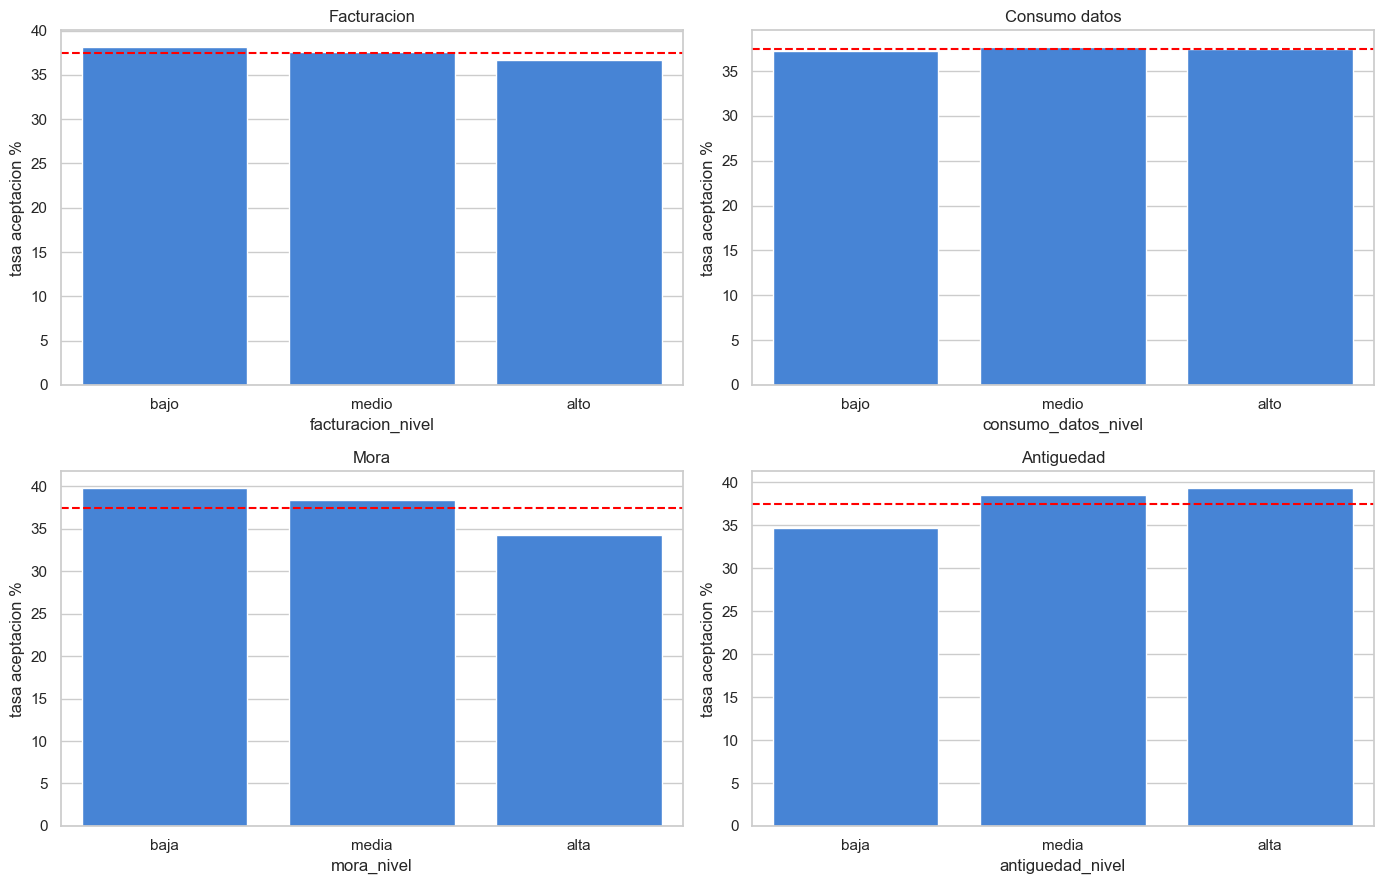

In [37]:
# Graficar tasas por niveles de facturacion, consumo, mora y antiguedad
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
segmentos = [
    (acc_facturacion, "facturacion_nivel", "Facturacion"),
    (acc_consumo, "consumo_datos_nivel", "Consumo datos"),
    (acc_mora, "mora_nivel", "Mora"),
    (acc_antiguedad, "antiguedad_nivel", "Antiguedad")
]

for ax, (tabla, col, titulo) in zip(axes.flatten(), segmentos):
    sns.barplot(data=tabla, x=col, y="tasa_aceptacion_pct", ax=ax, color="#2F80ED")
    ax.axhline(tasa_general, color="red", linestyle="--")
    ax.set_title(titulo)
    ax.set_ylabel("tasa aceptacion %")

plt.tight_layout()
plt.show()

**Hallazgo grafico:** mora y antiguedad muestran separaciones mas claras que consumo. Facturacion no debe leerse como mayor valor igual a mayor aceptacion.

## 6. Correlaciones entre predictoras numericas

In [38]:
# Correlacion entre variables numericas candidatas
corr = base_target[vars_numericas].corr()
corr

,antiguedad_meses,monto_facturado_prom,consumo_datos_gb_prom,consumo_voz_min_prom,consumo_sms_prom,uso_app_movistar_prom,monto_facturado_prom_6m,dias_mora_prom
antiguedad_meses,1.000000,-0.001999,0.000935,0.002543,-0.000431,-0.002971,-0.002062,-0.395739
monto_facturado_prom,-0.001999,1.000000,0.518894,0.003978,-0.000268,-0.007380,0.999615,0.001977
consumo_datos_gb_prom,0.000935,0.518894,1.000000,0.007189,-0.001662,-0.006317,0.518588,-0.000993
consumo_voz_min_prom,0.002543,0.003978,0.007189,1.000000,0.009732,0.004383,0.004058,-0.004732
consumo_sms_prom,-0.000431,-0.000268,-0.001662,0.009732,1.000000,0.002014,-0.000274,0.001916
uso_app_movistar_prom,-0.002971,-0.007380,-0.006317,0.004383,0.002014,1.000000,-0.007137,0.006033
monto_facturado_prom_6m,-0.002062,0.999615,0.518588,0.004058,-0.000274,-0.007137,1.000000,0.001976
dias_mora_prom,-0.395739,0.001977,-0.000993,-0.004732,0.001916,0.006033,0.001976,1.000000


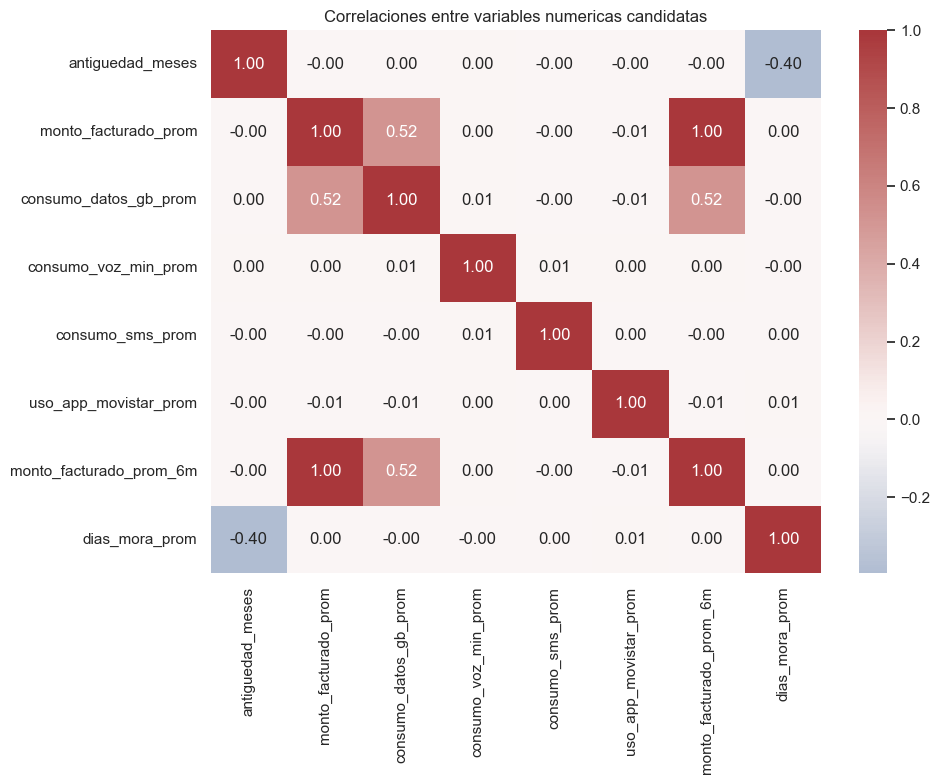

In [39]:
# Heatmap de correlaciones
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="vlag", center=0)
plt.title("Correlaciones entre variables numericas candidatas")
plt.tight_layout()
plt.show()

**Hallazgo:** las correlaciones altas indican posibles redundancias o multicolinealidad. No se elimina ninguna variable todavia.

## 7. Pruebas de hipotesis y valor practico

En esta seccion no se busca decidir automaticamente que variables entran al modelo. Se busca separar:

- diferencias estadisticamente significativas
- diferencias que ademas tienen magnitud comercial relevante

Con muchos registros, el p-value puede ser muy pequeno aunque la diferencia sea minima.

In [40]:
# Pruebas Mann-Whitney para numericas vs target
# Se usa una prueba no parametrica porque las distribuciones pueden no ser normales.
pruebas_num = []

for col in vars_numericas:
    acept = base_target.loc[base_target["target_aceptacion"] == 1, col].dropna()
    rech = base_target.loc[base_target["target_aceptacion"] == 0, col].dropna()
    stat, pvalue = mannwhitneyu(acept, rech, alternative="two-sided")
    pruebas_num.append([
        col,
        acept.median(),
        rech.median(),
        acept.median() - rech.median(),
        pvalue
    ])

pruebas_num = pd.DataFrame(pruebas_num, columns=[
    "variable", "mediana_aceptada", "mediana_rechazada", "diferencia_mediana", "p_value_mannwhitney"
])

pruebas_num.sort_values("p_value_mannwhitney")

,variable,mediana_aceptada,mediana_rechazada,diferencia_mediana,p_value_mannwhitney
7,dias_mora_prom,6.500000,7.166667,-0.666667,1.120776e-145
0,antiguedad_meses,94.000000,88.000000,6.000000,5.018247e-106
6,monto_facturado_prom_6m,76.020833,76.705000,-0.684167,1.650012e-10
1,monto_facturado_prom,76.060000,76.720000,-0.660000,1.685660e-10
2,consumo_datos_gb_prom,23.840833,23.634167,0.206667,1.725891e-02
4,consumo_sms_prom,8.000000,8.000000,0.000000,2.747339e-01
3,consumo_voz_min_prom,180.500000,180.833333,-0.333333,5.221295e-01
5,uso_app_movistar_prom,2.666667,2.666667,0.000000,9.337759e-01


**Hallazgos p-value numericas:**

- `antiguedad_meses` muestra una diferencia clara: mediana 94 meses en aceptadas vs 88 en rechazadas. Es estadisticamente significativa y tambien tiene interpretacion practica.
- `dias_mora_prom` tambien diferencia: aceptadas tienen mediana 6.5 vs 7.17 en rechazadas. La diferencia es pequena, pero consistente con que mayor mora podria asociarse a menor aceptacion.
- `monto_facturado_prom` y `monto_facturado_prom_6m` tienen p-value muy bajo, pero la diferencia de mediana es menor a 1 sol. Esto parece poco relevante comercialmente por si solo.
- `consumo_datos_gb_prom` tiene p-value bajo, pero la diferencia de mediana es apenas 0.21 GB. No parece una senal fuerte sola.
- `consumo_voz_min_prom`, `consumo_sms_prom` y `uso_app_movistar_prom` no muestran diferencias practicas importantes entre aceptadas y rechazadas.

In [41]:
# Pruebas chi-cuadrado para categoricas vs target
vars_categoricas = [
    "tipo_cliente", "edad_rango", "es_usuario_app", "canal",
    "tipo_oferta", "nombre_oferta", "elegible_mt", "es_movistar_total",
    "facturacion_nivel", "consumo_datos_nivel", "mora_nivel",
    "reclamos_tiene", "antiguedad_nivel"
]

pruebas_cat = []

for col in vars_categoricas:
    tabla = pd.crosstab(base_target[col], base_target["target_aceptacion"])
    chi2, pvalue, dof, expected = chi2_contingency(tabla)
    tasas = tasa_por_categoria(base_target, col, min_n=1)
    brecha_tasa = tasas["tasa_aceptacion_pct"].max() - tasas["tasa_aceptacion_pct"].min()
    pruebas_cat.append([col, chi2, pvalue, dof, brecha_tasa])

pruebas_cat = pd.DataFrame(pruebas_cat, columns=[
    "variable", "chi2", "p_value", "grados_libertad", "brecha_tasa_pp"
])

pruebas_cat.sort_values("p_value")

,variable,chi2,p_value,grados_libertad,brecha_tasa_pp
5,nombre_oferta,11875.873587,0.000000e+00,21,36.74
6,elegible_mt,7901.503227,0.000000e+00,1,24.85
4,tipo_oferta,11859.427041,0.000000e+00,5,35.93
0,tipo_cliente,1003.015183,1.577685e-218,2,6.49
10,mora_nivel,597.174486,2.114501e-130,2,5.53
12,antiguedad_nivel,453.563914,3.234800e-99,2,4.68
11,reclamos_tiene,169.387765,1.006668e-38,1,3.23
8,facturacion_nivel,37.734214,6.399109e-09,2,1.43
7,es_movistar_total,23.543940,1.220934e-06,1,1.80
9,consumo_datos_nivel,2.805012,2.459797e-01,2,0.39


**Hallazgos p-value categoricas y valor para negocio:**

- `tipo_oferta` y `nombre_oferta` presentan las mayores brechas. MT alcanza 69.70% de aceptacion observada frente a 34.09% en ofertas no MT; esto justifica un scoring especifico para MT dentro del motor NBO.
- `elegible_mt` parece muy asociado con aceptacion en el analisis simple, pero la asociacion esta confundida por la oferta presentada: todos los ofrecimientos MT se realizaron a elegibles. En ofertas no MT, la tasa de elegibles y no elegibles es casi identica.
- Mora, antiguedad y reclamos muestran diferencias utiles para priorizacion: pueden complementar el score y ayudar a evitar ofertas agresivas a clientes con alta friccion.
- `tipo_cliente` presenta una brecha descriptiva, aunque parte de su valor para MT ya esta incluido en la propia regla de elegibilidad.
- `edad_rango`, `canal` y `es_usuario_app` tienen poco efecto individual. No deben descartarse automaticamente: pueden aportar mediante interacciones con oferta, perfil o momento.
- Facturacion tiene p-value bajo, pero una brecha comercial pequena. No debe usarse sola como sinonimo de propension.

Con el gran volumen de datos, el p-value detecta diferencias pequenas. Para la solucion pesan mas la magnitud de la brecha, la disponibilidad de la variable antes del ofrecimiento y su utilidad operativa.

## 8. Analisis temporal integrado

Se revisa si la aceptacion cambia por mes. Esto es descriptivo; no se asume causalidad.

In [42]:
# Crear mes y calcular evolucion temporal de ofrecimientos y aceptacion
analitica["fecha"] = pd.to_datetime(analitica["fecha"])
analitica["mes"] = analitica["fecha"].dt.to_period("M").astype(str)

temporal = analitica.groupby("mes").agg(
    ofrecimientos=("resultado", "size"),
    aceptadas=("resultado", lambda x: (x == "aceptada").sum()),
    rechazadas=("resultado", lambda x: (x == "rechazada").sum()),
    pendientes=("resultado", lambda x: (x == "pendiente").sum())
).reset_index()

temporal["tasa_aceptacion_pct"] = (temporal["aceptadas"] / (temporal["aceptadas"] + temporal["rechazadas"]) * 100).round(2)
temporal

,mes,ofrecimientos,aceptadas,rechazadas,pendientes,tasa_aceptacion_pct
0,2026-01,49900,15711,26576,7613,37.15
1,2026-02,49922,16012,26470,7440,37.69
2,2026-03,49763,15855,26396,7512,37.53
3,2026-04,50251,15987,26613,7651,37.53
4,2026-05,50366,15972,26685,7709,37.44
5,2026-06,49910,15877,26464,7569,37.50


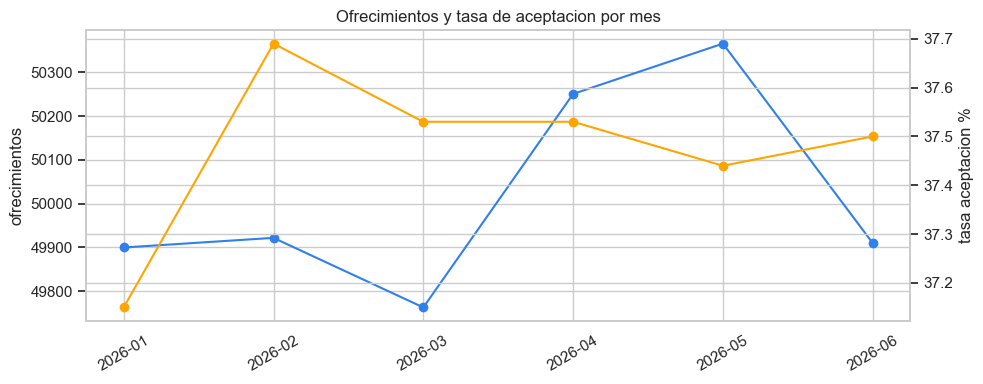

In [43]:
# Graficar ofrecimientos y tasa de aceptacion por mes
fig, ax1 = plt.subplots(figsize=(10, 4))

ax1.plot(temporal["mes"], temporal["ofrecimientos"], marker="o", color="#2F80ED")
ax1.set_ylabel("ofrecimientos")
ax1.tick_params(axis="x", rotation=30)

ax2 = ax1.twinx()
ax2.plot(temporal["mes"], temporal["tasa_aceptacion_pct"], marker="o", color="orange")
ax2.set_ylabel("tasa aceptacion %")

plt.title("Ofrecimientos y tasa de aceptacion por mes")
plt.tight_layout()
plt.show()

In [44]:
# Tasa de aceptacion por mes y tipo de oferta
mes_tipo = base_target.copy()
mes_tipo["fecha"] = pd.to_datetime(mes_tipo["fecha"])
mes_tipo["mes"] = mes_tipo["fecha"].dt.to_period("M").astype(str)

mes_tipo_tabla = mes_tipo.groupby(["mes", "tipo_oferta"]).agg(
    ofrecimientos=("target_aceptacion", "size"),
    aceptadas=("target_aceptacion", "sum")
).reset_index()
mes_tipo_tabla["tasa_aceptacion_pct"] = (mes_tipo_tabla["aceptadas"] / mes_tipo_tabla["ofrecimientos"] * 100).round(2)
mes_tipo_tabla.head()

,mes,tipo_oferta,ofrecimientos,aceptadas,tasa_aceptacion_pct
0,2026-01,equipo,6041,2046,33.87
1,2026-01,movistar_total,4061,2798,68.90
2,2026-01,paquete_adicional,5982,1979,33.08
3,2026-01,plan_hogar,12145,4062,33.45
4,2026-01,plan_movil,8006,2729,34.09


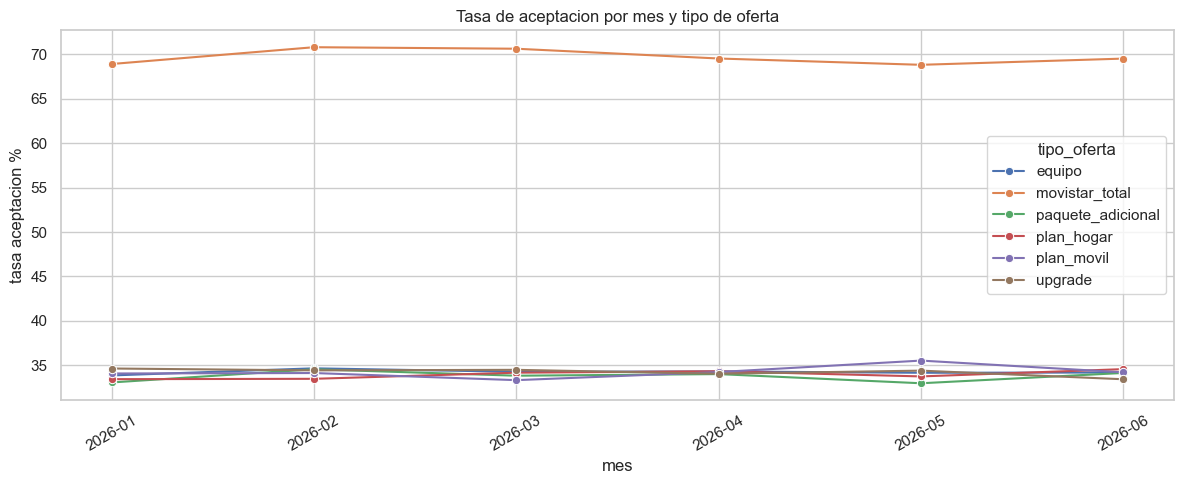

In [45]:
# Graficar tasa por mes y tipo de oferta
plt.figure(figsize=(12, 5))
sns.lineplot(data=mes_tipo_tabla, x="mes", y="tasa_aceptacion_pct", hue="tipo_oferta", marker="o")
plt.title("Tasa de aceptacion por mes y tipo de oferta")
plt.ylabel("tasa aceptacion %")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

**Hallazgo temporal:** la tasa general cambia poco por mes. La diferencia visual mas fuerte viene del tipo de oferta, especialmente Movistar Total frente al resto.

## 9. Analisis especifico Movistar Total

Se analiza MT porque es prioridad del reto. Se consideran solo ofrecimientos donde `oferta_es_mt = True`.

In [46]:
# Base de ofrecimientos Movistar Total con resultado cerrado
mt_target = base_target[base_target["oferta_es_mt"] == True].copy()
mt_target.shape

(24207, 50)

In [47]:
# Tasa general de aceptacion MT
pd.DataFrame({
    "ofrecimientos_mt_cerrados": [len(mt_target)],
    "aceptadas_mt": [mt_target["target_aceptacion"].sum()],
    "rechazadas_mt": [(mt_target["target_aceptacion"] == 0).sum()],
    "tasa_aceptacion_mt_pct": [round(mt_target["target_aceptacion"].mean() * 100, 2)]
})

,ofrecimientos_mt_cerrados,aceptadas_mt,rechazadas_mt,tasa_aceptacion_mt_pct
0,24207,16872,7335,69.7


In [48]:
# Aceptacion MT por canal
mt_canal = tasa_por_categoria(mt_target, "canal", min_n=30)
mt_canal

,canal,ofrecimientos,aceptadas,tasa_aceptacion_pct
2,digital,8406,5872,69.85
0,call in,4885,3405,69.70
1,call out,3665,2553,69.66
3,tienda,7251,5042,69.54


In [49]:
# Aceptacion MT por tipo de cliente
mt_tipo_cliente = tasa_por_categoria(mt_target, "tipo_cliente", min_n=30)
mt_tipo_cliente

,tipo_cliente,ofrecimientos,aceptadas,tasa_aceptacion_pct
0,postpago,24207,16872,69.7


In [50]:
# Aceptacion MT por edad
mt_edad = tasa_por_categoria(mt_target, "edad_rango", min_n=30)
mt_edad

,edad_rango,ofrecimientos,aceptadas,tasa_aceptacion_pct
3,46-55,4278,3012,70.41
2,36-45,5836,4101,70.27
1,26-35,6907,4818,69.76
0,18-25,3506,2423,69.11
4,56-65,2493,1717,68.87
5,65+,1187,801,67.48


In [51]:
# Aceptacion MT por uso de app
mt_app = tasa_por_categoria(mt_target, "es_usuario_app", min_n=30)
mt_app

,es_usuario_app,ofrecimientos,aceptadas,tasa_aceptacion_pct
0,False,5958,4167,69.94
1,True,18249,12705,69.62


In [52]:
# Aceptacion MT por variante especifica
mt_variante = tasa_por_categoria(mt_target, "nombre_oferta", min_n=30)
mt_variante

,nombre_oferta,ofrecimientos,aceptadas,tasa_aceptacion_pct
2,movistar total plus,8104,5687,70.18
0,movistar total basico,8022,5584,69.61
1,movistar total max,8081,5601,69.31


In [53]:
# Aceptacion MT por facturacion y consumo
mt_target["facturacion_nivel"] = pd.qcut(mt_target["monto_facturado_prom"], q=3, labels=["bajo", "medio", "alto"])
mt_target["consumo_datos_nivel"] = pd.qcut(mt_target["consumo_datos_gb_prom"], q=3, labels=["bajo", "medio", "alto"])

pd.concat([
    tasa_por_categoria(mt_target, "facturacion_nivel", min_n=30).assign(variable="facturacion_nivel"),
    tasa_por_categoria(mt_target, "consumo_datos_nivel", min_n=30).assign(variable="consumo_datos_nivel")
])

,facturacion_nivel,ofrecimientos,aceptadas,tasa_aceptacion_pct,variable,consumo_datos_nivel
1,medio,8065,5641,69.94,facturacion_nivel,NaN
0,bajo,8075,5627,69.68,facturacion_nivel,NaN
2,alto,8067,5604,69.47,facturacion_nivel,NaN
1,NaN,8070,5641,69.90,consumo_datos_nivel,medio
2,NaN,8065,5627,69.77,consumo_datos_nivel,alto
0,NaN,8072,5604,69.43,consumo_datos_nivel,bajo


In [54]:
# Motivos de rechazo en ofertas MT
mt_rechazos = analitica[(analitica["oferta_es_mt"] == True) & (analitica["resultado"] == "rechazada")]
mt_rechazos["motivo_rechazo"].value_counts(dropna=False).to_frame("rechazos_mt").assign(
    porcentaje=lambda x: (x["rechazos_mt"] / len(mt_rechazos) * 100).round(2)
)

,rechazos_mt,porcentaje
motivo_rechazo,,
precio,2555,34.83
no_necesita,1472,20.07
mal_momento,1121,15.28
ya_tiene_similar,1112,15.16
no_confia,741,10.10
otro,334,4.55


In [55]:
# Verificar si rebate tiene un resultado posterior observable
pd.crosstab(analitica["es_rebate"], analitica["resultado"], margins=True)

resultado,aceptada,pendiente,rechazada,All
es_rebate,,,,
False,95414,45494,111632,252540
True,0,0,47572,47572
All,95414,45494,159204,300112


**Hallazgo sobre rebate:** todos los casos con rebate permanecen registrados como rechazados. Con esta tabla no se puede afirmar que el rebate funcione o no, porque falta el resultado posterior a la contraoferta. Para el prototipo, el motivo de rechazo puede alimentar un speech personalizado, pero la efectividad del rebate debera medirse con un nuevo evento de seguimiento.

### Graficos Movistar Total

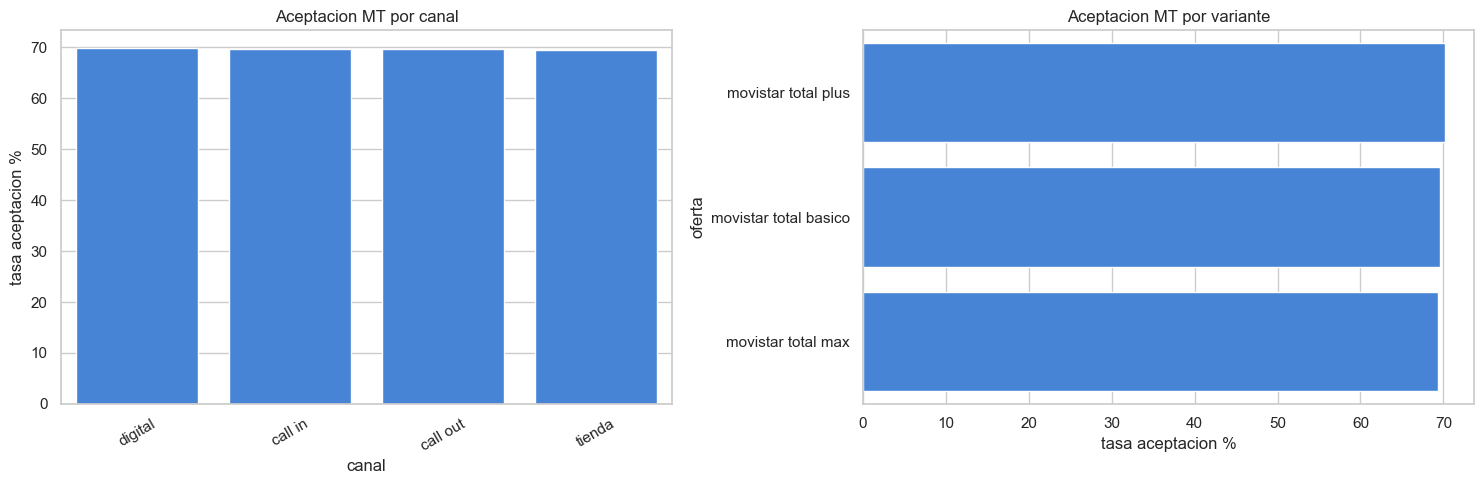

In [56]:
# Graficar aceptacion MT por canal y variante
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.barplot(data=mt_canal, x="canal", y="tasa_aceptacion_pct", ax=axes[0], color="#2F80ED")
axes[0].set_title("Aceptacion MT por canal")
axes[0].set_ylabel("tasa aceptacion %")
axes[0].tick_params(axis="x", rotation=30)

sns.barplot(data=mt_variante, y="nombre_oferta", x="tasa_aceptacion_pct", ax=axes[1], color="#2F80ED")
axes[1].set_title("Aceptacion MT por variante")
axes[1].set_xlabel("tasa aceptacion %")
axes[1].set_ylabel("oferta")

plt.tight_layout()
plt.show()

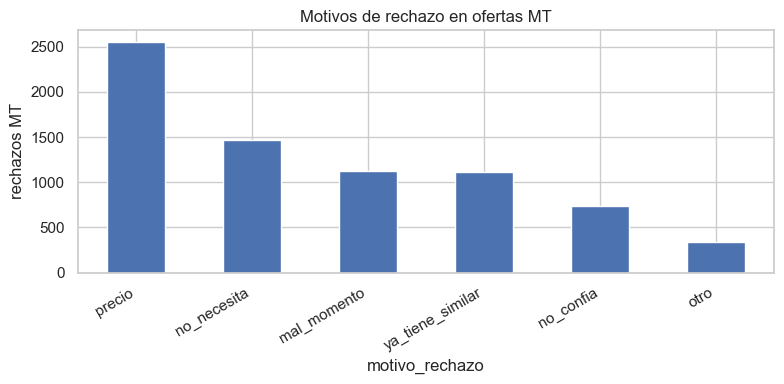

In [57]:
# Graficar motivos de rechazo MT
plt.figure(figsize=(8, 4))
mt_rechazos["motivo_rechazo"].value_counts().plot(kind="bar")
plt.title("Motivos de rechazo en ofertas MT")
plt.ylabel("rechazos MT")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

**Hallazgos Movistar Total:**

- Las ofertas MT tienen una aceptacion observada cercana a 69.70%, muy por encima de la tasa general.
- Por canal, las diferencias son pequenas: digital 69.85%, call in 69.70%, call out 69.66% y tienda 69.54%. El canal por si solo no parece cambiar mucho la aceptacion MT.
- Por variante, `movistar total plus` lidera con 70.18%, seguida de `movistar total basico` con 69.61% y `movistar total max` con 69.31%. La diferencia existe, pero no es enorme.
- Por edad, los rangos 46-55 y 36-45 aparecen ligeramente mejor para MT; 65+ es el mas bajo.
- El uso de app casi no cambia la aceptacion MT: no usuarios 69.94% vs usuarios 69.62%.
- El principal motivo de rechazo MT es `precio` con 34.83% de rechazos, seguido por `no_necesita` con 20.07%. Esto apunta a trabajar argumentos de valor, ahorro y necesidad del bundle.

## 10. Hallazgos de valor para negocio

- La oferta presentada es la senal descriptiva mas fuerte. MT registra 69.70% de aceptacion entre ofrecimientos cerrados, frente a 34.09% en ofertas no MT.
- Ese resultado no significa que MT causara por si solo la mejora: MT solo fue ofrecido a clientes elegibles. El modelo debera validar el patron con una separacion temporal y controlar el perfil del cliente.
- `elegible_mt` funciona como filtro comercial. Entre ofertas no MT, elegibles y no elegibles tienen casi la misma aceptacion; su valor consiste en indicar a quienes se puede recomendar MT.
- Canal y uso de app tienen diferencias individuales muy pequenas. El canal puede mantenerse como contexto, pero no debe presentarse como determinante ni como canal ganador.
- Antiguedad, mora y reclamos aportan senales mas utiles que facturacion aislada. Permiten priorizar propension y proteger la experiencia de clientes con friccion.
- En MT, `precio` explica 34.83% de los rechazos y `no_necesita` 20.07%. El mensaje debe mostrar ahorro y necesidad concreta del bundle, no solo nombrar el producto.
- El 15.16% de intentos no llego a contacto. Una mejora de contactabilidad puede elevar conversion incluso antes de optimizar aceptacion.
- El dataset no permite medir la efectividad del rebate porque no registra una respuesta posterior; este es un requerimiento de trazabilidad E2E para la propuesta.

## 11. Hallazgos finales del EDA integrado

- El target de aceptacion se define con `aceptada = 1` y `rechazada = 0`; `pendiente` se reserva para contactabilidad.
- La unidad de analisis se mantiene en un ofrecimiento y el modelo debera puntuar combinaciones cliente-oferta.
- Para el caso prioritario MT se usan `elegible_mt` como filtro del cliente y `oferta_es_mt` como indicador de la oferta presentada. `es_movistar_total` solo indica que el cliente ya tenia MT.
- Las pruebas estadisticas sirven como evidencia de asociacion, pero la seleccion de variables debe considerar magnitud, fuga de informacion, validacion temporal y valor comercial.
- No existe un canal ganador en el EDA. La hiperpersonalizacion debe centrarse en cliente + oferta + contexto, y comprobar interacciones durante el modelado.
- El siguiente paso es construir el dataset de modelado sin variables posteriores al ofrecimiento y comparar un modelo general NBO con un analisis especifico para MT.

## 12. Como se traduce este EDA a la solucion

El motor propuesto puede trabajar en dos etapas:

1. Estimar `probabilidad_contacto` para priorizar el momento o medio con mayor posibilidad de llegar al cliente.
2. Entre clientes contactables, estimar `probabilidad_aceptacion` para cada combinacion cliente-oferta y ordenar las ofertas. Para clientes con `elegible_mt = True`, las variantes MT entran como caso prioritario.

La salida util para el asesor o canal digital seria: cliente, oferta recomendada, probabilidad de aceptacion, razones principales de la recomendacion, canal contextual, beneficio esperado y speech sugerido. El canal no se presenta como determinante porque el EDA no encontro diferencias relevantes por si solo.

### Variables que pueden y no pueden entrar al modelo

| Uso | Variables | Motivo |
|---|---|---|
| Predictoras disponibles antes de ofrecer | perfil, consumo, facturacion, antiguedad, mora, reclamos, engagement, canal, atributos de la oferta | Estan disponibles en el momento de generar la recomendacion. |
| Regla del caso MT | `elegible_mt`, `oferta_es_mt`, `es_movistar_total` | Permiten distinguir cliente elegible, oferta MT y cliente que ya tenia MT. |
| Target | `resultado` transformado a `target_aceptacion` | Indica aceptacion o rechazo en ofrecimientos contactados. |
| No usar como predictoras de aceptacion | `motivo_rechazo`, `es_rebate`, `medio_probatorio`, `resultado`, `target_aceptacion` | Se conocen durante o despues del ofrecimiento y producirian fuga de informacion. |
| Modelo secundario futuro | `motivo_rechazo` como target entre rechazados | Permitiria anticipar la objecion probable y generar un speech de rebate personalizado. |

La validacion del modelo debe ser temporal: entrenar con meses anteriores y evaluar en un mes posterior. Asi se mide mejor si la recomendacion funcionaria en una campania futura.

## 13. Interacciones cliente-oferta

Se revisa si una oferta encaja con el consumo, precio y productos del cliente. Este analisis es descriptivo y no entrena ningun modelo. Las comparaciones se hacen sobre ofrecimientos cerrados.

In [58]:
# Crear segmentos de cliente para revisar interacciones con la oferta
interacciones = base_target.copy()

interacciones["producto_actual"] = "otros"
interacciones.loc[interacciones["tiene_movil"] & ~interacciones["tiene_hogar"], "producto_actual"] = "solo_movil"
interacciones.loc[~interacciones["tiene_movil"] & interacciones["tiene_hogar"], "producto_actual"] = "solo_hogar"
interacciones.loc[interacciones["tiene_movil"] & interacciones["tiene_hogar"], "producto_actual"] = "movil_hogar"
interacciones.loc[interacciones["es_movistar_total"], "producto_actual"] = "ya_tiene_mt"

interacciones["antiguedad_nivel"] = pd.qcut(
    interacciones["antiguedad_meses"], 3, labels=["baja", "media", "alta"]
)

interacciones["friccion_alta"] = (
    (interacciones["dias_mora_prom"] >= clientes["dias_mora_prom"].quantile(0.75)) |
    (interacciones["meses_moroso"] >= clientes["meses_moroso"].quantile(0.75)) |
    (interacciones["n_reclamos"] > 0)
)
interacciones["tiene_reclamos"] = interacciones["n_reclamos"] > 0

**Criterio usado:** `producto_actual` resume movil y hogar; `antiguedad_nivel` usa terciles; `friccion_alta` se activa por mora alta, dos o mas meses moroso o al menos un reclamo. Estas categorias se usan para interpretar cruces, no sustituyen automaticamente las variables originales.

In [59]:
# Crear features de encaje entre consumo, facturacion y oferta
interacciones["oferta_ilimitada"] = interacciones["gb_incluidos"] == 9999

interacciones["diferencia_gb"] = np.where(
    (interacciones["gb_incluidos"] > 0) & ~interacciones["oferta_ilimitada"],
    interacciones["gb_incluidos"] - interacciones["consumo_datos_gb_prom"],
    np.nan
)

interacciones["encaje_gb"] = "no_aplica"
interacciones.loc[interacciones["oferta_ilimitada"], "encaje_gb"] = "ilimitada"
interacciones.loc[interacciones["diferencia_gb"] < 0, "encaje_gb"] = "no_cubre_consumo"
interacciones.loc[interacciones["diferencia_gb"].between(0, 10), "encaje_gb"] = "cubre_hasta_10gb_extra"
interacciones.loc[interacciones["diferencia_gb"] > 10, "encaje_gb"] = "cubre_mas_10gb_extra"

interacciones["precio_relativo"] = (
    interacciones["precio_mensual"] / interacciones["monto_facturado_prom"]
)
interacciones["encaje_precio"] = pd.cut(
    interacciones["precio_relativo"],
    [0, 0.5, 1, 1.5, np.inf],
    labels=["hasta_50pct", "50_a_100pct", "100_a_150pct", "mas_150pct"],
    include_lowest=True
)

**Criterio usado:** `diferencia_gb` compara GB ofrecidos menos consumo promedio; el valor 9999 se trata como ilimitado. `precio_relativo` compara precio mensual de la oferta contra facturacion actual. Este ultimo indicador requiere cautela porque el precio puede ser reemplazo de plan, cargo adicional o precio de un bundle.

In [60]:
# Crear reglas simples de compatibilidad y producto faltante
oferta_movil = (
    (interacciones["segmento_objetivo"] == "movil") &
    interacciones["tipo_oferta"].isin(["plan_movil", "upgrade", "equipo", "paquete_adicional"])
)
oferta_hogar = (
    (interacciones["segmento_objetivo"] == "hogar") &
    interacciones["tipo_oferta"].isin(["plan_hogar", "upgrade", "equipo"])
)
oferta_ambos = (
    (interacciones["segmento_objetivo"] == "ambos") &
    (interacciones["tipo_oferta"] == "paquete_adicional")
)

interacciones["compatibilidad_producto"] = False
interacciones.loc[oferta_movil, "compatibilidad_producto"] = interacciones.loc[oferta_movil, "tiene_movil"]
interacciones.loc[oferta_hogar, "compatibilidad_producto"] = interacciones.loc[oferta_hogar, "tiene_hogar"]
interacciones.loc[oferta_ambos, "compatibilidad_producto"] = interacciones.loc[oferta_ambos, "tiene_movil"] | interacciones.loc[oferta_ambos, "tiene_hogar"]
interacciones.loc[interacciones["oferta_es_mt"], "compatibilidad_producto"] = interacciones.loc[interacciones["oferta_es_mt"], "elegible_mt"]

interacciones["oferta_completa_producto_faltante"] = (
    (interacciones["tiene_movil"] & ~interacciones["tiene_hogar"] & (interacciones["tipo_oferta"] == "plan_hogar")) |
    (~interacciones["tiene_movil"] & interacciones["tiene_hogar"] & (interacciones["tipo_oferta"] == "plan_movil"))
)

**Criterio usado:** compatibilidad significa que el cliente ya posee el servicio base necesario; para MT exige `elegible_mt`. `oferta_completa_producto_faltante` identifica cross-sell de hogar a quien solo tiene movil o de movil a quien solo tiene hogar. Son reglas propuestas y deben validarse con negocio antes de produccion.

In [61]:
# Comparar senal global y senal sin ofertas MT para cada feature de encaje
pruebas_encaje = []
for muestra, datos in [("total", interacciones), ("sin_mt", interacciones[~interacciones["oferta_es_mt"]])]:
    for variable in ["encaje_gb", "encaje_precio", "compatibilidad_producto", "oferta_completa_producto_faltante"]:
        tabla = pd.crosstab(datos[variable], datos["target_aceptacion"])
        chi2, pvalue, dof, esperado = chi2_contingency(tabla)
        v = np.sqrt(chi2 / (tabla.values.sum() * min(tabla.shape[0] - 1, tabla.shape[1] - 1)))
        tasas = datos.groupby(variable, observed=False)["target_aceptacion"].mean() * 100
        pruebas_encaje.append([muestra, variable, pvalue, v, tasas.max() - tasas.min()])

pruebas_encaje = pd.DataFrame(pruebas_encaje, columns=[
    "muestra", "variable", "p_value", "cramer_v", "brecha_max_pp"
])
pruebas_encaje.round(4)

,muestra,variable,p_value,cramer_v,brecha_max_pp
0,total,encaje_gb,0.0000,0.1021,14.5502
1,total,encaje_precio,0.0000,0.1042,11.3275
2,total,compatibilidad_producto,0.0000,0.0458,5.0385
3,total,oferta_completa_producto_faltante,0.0000,0.0371,4.5937
4,sin_mt,encaje_gb,0.6923,0.0031,0.7476
5,sin_mt,encaje_precio,0.4676,0.0033,0.4510
6,sin_mt,compatibilidad_producto,0.0350,0.0044,0.4593
7,sin_mt,oferta_completa_producto_faltante,0.0750,0.0037,0.4347


**Hallazgo de encaje:** `encaje_gb` y `encaje_precio` parecen relevantes en el total, pero pierden completamente la senal al excluir MT: p-values 0.692 y 0.468, con V cercano a 0.003. La aparente relacion proviene de que MT tiene mas GB, mayor precio y mayor aceptacion historica. Compatibilidad y producto faltante tambien tienen efecto practico casi nulo dentro de ofertas no MT.

In [62]:
# Mostrar tasas de aceptacion de las features de encaje
tasas_encaje = []
for muestra, datos in [("total", interacciones), ("sin_mt", interacciones[~interacciones["oferta_es_mt"]])]:
    for variable in ["encaje_gb", "encaje_precio", "compatibilidad_producto", "oferta_completa_producto_faltante"]:
        tabla = datos.groupby(variable, observed=False)["target_aceptacion"].agg(["size", "mean"]).reset_index()
        tabla["mean"] = (tabla["mean"] * 100).round(2)
        tabla["muestra"] = muestra
        tabla["variable"] = variable
        tabla = tabla.rename(columns={variable: "categoria", "size": "ofrecimientos", "mean": "tasa_aceptacion_pct"})
        tasas_encaje.append(tabla[["muestra", "variable", "categoria", "ofrecimientos", "tasa_aceptacion_pct"]])

pd.concat(tasas_encaje, ignore_index=True)

,muestra,variable,categoria,ofrecimientos,tasa_aceptacion_pct
0,total,encaje_gb,cubre_hasta_10gb_extra,14178,38.81
1,total,encaje_gb,cubre_mas_10gb_extra,29001,45.79
2,total,encaje_gb,ilimitada,19999,48.60
3,total,encaje_gb,no_aplica,145536,34.05
4,total,encaje_gb,no_cubre_consumo,45904,37.82
5,total,encaje_precio,hasta_50pct,83935,34.23
6,total,encaje_precio,50_a_100pct,56774,34.13
7,total,encaje_precio,100_a_150pct,41321,34.63
8,total,encaje_precio,mas_150pct,72588,45.46
9,total,compatibilidad_producto,False,67075,33.76


**Lectura para negocio:** dentro de ofertas no MT, cubrir el consumo, tener un precio relativo menor, ser compatible o completar un producto faltante no cambia de forma relevante la aceptacion observada. Esto sugiere que el dataset sintetico no incorporo con fuerza estas reglas de encaje. Aun asi, compatibilidad y producto faltante deben conservarse como reglas comerciales, no como evidencia predictiva demostrada.

In [63]:
# Medir diferencias de perfil dentro de cada tipo de oferta
resumen_interacciones = []
for perfil in ["producto_actual", "tipo_cliente", "antiguedad_nivel", "friccion_alta", "tiene_reclamos"]:
    for tipo, datos in interacciones.groupby("tipo_oferta"):
        tabla = pd.crosstab(datos[perfil], datos["target_aceptacion"])
        chi2, pvalue, dof, esperado = chi2_contingency(tabla)
        v = np.sqrt(chi2 / (tabla.values.sum() * min(tabla.shape[0] - 1, tabla.shape[1] - 1)))
        tasas = datos.groupby(perfil, observed=False)["target_aceptacion"].mean() * 100
        resumen_interacciones.append([perfil, tipo, len(datos), tasas.max() - tasas.min(), pvalue, v])

resumen_interacciones = pd.DataFrame(resumen_interacciones, columns=[
    "perfil", "tipo_oferta", "ofrecimientos", "brecha_max_pp", "p_value", "cramer_v"
])
resumen_interacciones.round(4)

,perfil,tipo_oferta,ofrecimientos,brecha_max_pp,p_value,cramer_v
0,producto_actual,equipo,36344,2.8335,0.1212,0.0126
1,producto_actual,movistar_total,24207,0.0000,1.0000,NaN
2,producto_actual,paquete_adicional,36094,4.2023,0.0003,0.0230
3,producto_actual,plan_hogar,72956,1.4444,0.1169,0.0090
4,producto_actual,plan_movil,48375,2.0805,0.0860,0.0117
5,producto_actual,upgrade,36642,2.8993,0.1227,0.0126
6,tipo_cliente,equipo,36344,1.6858,0.2132,0.0092
7,tipo_cliente,movistar_total,24207,0.0000,1.0000,NaN
8,tipo_cliente,paquete_adicional,36094,1.0060,0.1853,0.0097
9,tipo_cliente,plan_hogar,72956,0.6246,0.6647,0.0033


**Hallazgo de interacciones:** producto actual y tipo de cliente casi no diferencian aceptacion dentro de una misma familia de oferta. Antiguedad y friccion mantienen senal en todas las familias y la brecha es mayor en MT: 9.38 puntos por antiguedad y 6.97 puntos por friccion. Reclamos tambien reducen aceptacion, especialmente en MT y paquetes adicionales.

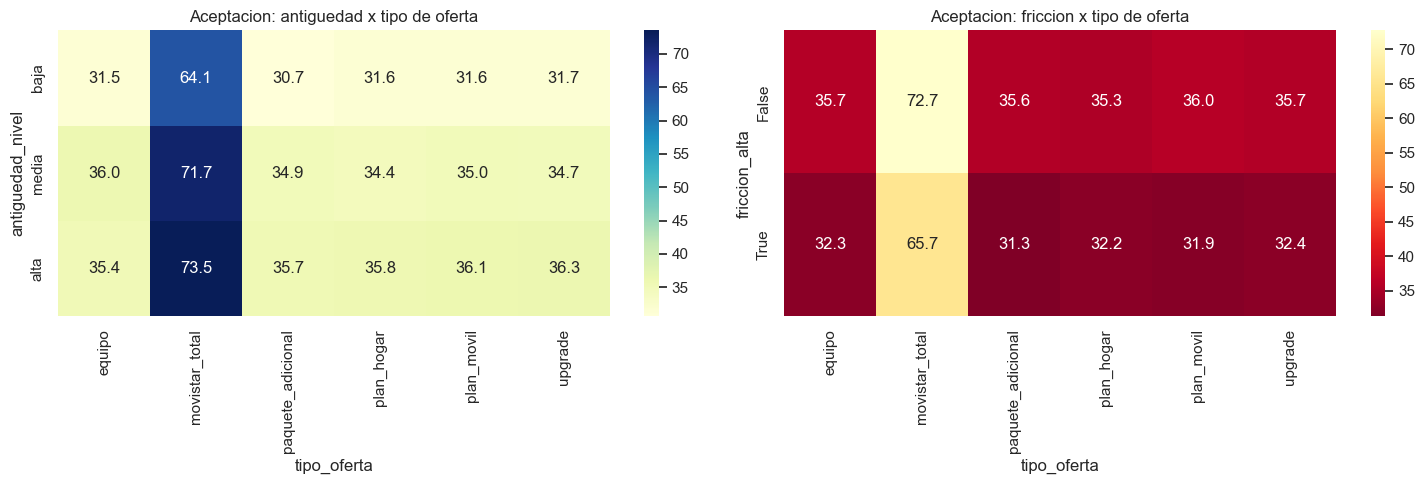

In [64]:
# Graficar las interacciones con mayor senal descriptiva
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

tabla_antiguedad = interacciones.pivot_table(
    index="antiguedad_nivel", columns="tipo_oferta", values="target_aceptacion", aggfunc="mean", observed=False
) * 100
sns.heatmap(tabla_antiguedad, annot=True, fmt=".1f", cmap="YlGnBu", ax=axes[0])
axes[0].set_title("Aceptacion: antiguedad x tipo de oferta")

tabla_friccion = interacciones.pivot_table(
    index="friccion_alta", columns="tipo_oferta", values="target_aceptacion", aggfunc="mean", observed=False
) * 100
sns.heatmap(tabla_friccion, annot=True, fmt=".1f", cmap="YlOrRd_r", ax=axes[1])
axes[1].set_title("Aceptacion: friccion x tipo de oferta")

plt.tight_layout()
plt.show()

**Hallazgo grafico:** los clientes de mayor antiguedad aceptan mas en todas las ofertas, mientras que la friccion reduce aceptacion de manera consistente. La separacion es especialmente visible en MT, por lo que estas interacciones tienen sentido para priorizacion y para proteger la experiencia del cliente.

In [65]:
# Evaluar si alguna variante MT funciona mejor entre elegibles
mt_interacciones = interacciones[interacciones["oferta_es_mt"]].copy()
tabla_mt = pd.crosstab(mt_interacciones["nombre_oferta"], mt_interacciones["target_aceptacion"])
chi2_mt, p_mt, dof_mt, esperado_mt = chi2_contingency(tabla_mt)
v_mt = np.sqrt(chi2_mt / (tabla_mt.values.sum() * min(tabla_mt.shape[0] - 1, tabla_mt.shape[1] - 1)))

mt_variantes = mt_interacciones.groupby("nombre_oferta")["target_aceptacion"].agg(["size", "mean"]).reset_index()
mt_variantes["tasa_aceptacion_pct"] = (mt_variantes["mean"] * 100).round(2)
mt_variantes["p_value_variantes"] = p_mt
mt_variantes["cramer_v_variantes"] = v_mt
mt_variantes.drop(columns="mean")

,nombre_oferta,size,tasa_aceptacion_pct,p_value_variantes,cramer_v_variantes
0,movistar total basico,8022,69.61,0.477563,0.007814
1,movistar total max,8081,69.31,0.477563,0.007814
2,movistar total plus,8104,70.18,0.477563,0.007814


**Hallazgo variantes MT:** Basico, Plus y Max tienen tasas entre 69.31% y 70.18%. La diferencia no es significativa (`p = 0.478`, V = 0.0078). Tampoco aparece una variante claramente superior al cruzar con antiguedad, friccion o reclamos. Con estos datos no se puede sustentar una personalizacion entre variantes MT por aceptacion.

## 14. Decision de features antes del modelado

**Conservar como candidatas:**

- Antiguedad y su interaccion con tipo de oferta: senal consistente y mayor brecha en MT.
- Mora y reclamos, junto con interacciones por oferta: senales de friccion utiles para propension y experiencia.
- `oferta_es_mt` y `elegible_mt`: como indicador de oferta y regla comercial, manteniendo clara su seleccion historica.
- Atributos originales de cliente y oferta para permitir que el modelo encuentre relaciones sin depender solo de categorias creadas.

**Conservar como reglas, pero no como predictoras demostradas:**

- `compatibilidad_producto` y `oferta_completa_producto_faltante`. Tienen sentido comercial aunque el historial sintetico casi no muestre efecto.

**No conservar por ahora como features categorizadas:**

- `encaje_gb` y `encaje_precio`: no muestran senal dentro de ofertas no MT. Se pueden probar sus versiones continuas `diferencia_gb` y `precio_relativo` mediante validacion y eliminarlas si no agregan valor.
- Variante MT como regla de propension: no hay diferencias suficientes entre Basico, Plus y Max.
- Tipo de cliente o producto actual interactuados masivamente con oferta: las diferencias dentro de cada familia son pequenas y pueden duplicar reglas ya presentes.

**Riesgos:**

- Sesgo de seleccion: todas las ofertas MT fueron dirigidas a elegibles; la alta aceptacion MT no es un efecto causal demostrado.
- Leakage temporal: perfil, consumo, mora y reclamos son agregados de enero-junio y pueden incluir informacion posterior a campañas tempranas.
- Repeticion por cliente: las pruebas simples tratan ofrecimientos como independientes. La validacion final debe agrupar por `cliente_id` y utilizar snapshots disponibles antes del ofrecimiento.

No se entrena ningun modelo en esta seccion.

## 15. Preparacion del baseline sin entrenamiento

El target utiliza solo ofrecimientos con resultado cerrado:

- `aceptada = 1`
- `rechazada = 0`
- `pendiente` queda fuera

En esta seccion se reservan Train y Test por cliente, y se construye el Pipeline. Todavia no se ejecuta `fit` ni se consulta el Test para evaluar el modelo.

In [66]:
# Importar herramientas para split agrupado y Pipeline
from sklearn.model_selection import GroupShuffleSplit, GroupKFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression

In [67]:
# Preparar una copia de la base cerrada para modelado
modelado = base_target.copy()

# Separar el codigo 9999 para que no se trate como una cantidad normal de GB
modelado["oferta_ilimitada"] = modelado["gb_incluidos"] == 9999
modelado["gb_incluidos_modelo"] = modelado["gb_incluidos"].replace(9999, np.nan)

**Decisión:** `gb_incluidos = 9999` significa ilimitado, no 9,999 GB reales. Se crea `oferta_ilimitada` y la cantidad queda como faltante para que el Pipeline la impute usando exclusivamente el Train de cada fold.

In [68]:
# Definir columnas numericas y categoricas candidatas
variables_numericas_modelo = [
    "antiguedad_meses",
    "monto_facturado_prom",
    "consumo_datos_gb_prom",
    "consumo_voz_min_prom",
    "consumo_sms_prom",
    "uso_app_movistar_prom",
    "monto_facturado_prom_6m",
    "dias_mora_prom",
    "precio_mensual",
    "ahorro_pct",
    "gb_incluidos_modelo"
]

variables_categoricas_modelo = [
    "tipo_cliente",
    "tiene_movil",
    "tiene_hogar",
    "oferta_hogar_id",
    "tiene_internet_hogar",
    "es_movistar_total",
    "elegible_mt",
    "plan_actual_id",
    "edad_rango",
    "ubicacion_departamento",
    "es_usuario_app",
    "meses_moroso",
    "n_reclamos",
    "n_actividad_canal",
    "canal_mas_usado",
    "oferta_id",
    "canal",
    "tipo_oferta",
    "oferta_es_mt",
    "segmento_objetivo",
    "cluster_hogar",
    "oferta_ilimitada"
]

columnas_X = variables_numericas_modelo + variables_categoricas_modelo
pd.DataFrame({
    "columna": columnas_X,
    "tipo_pipeline": ["numerica"] * len(variables_numericas_modelo) + ["categorica"] * len(variables_categoricas_modelo)
})

,columna,tipo_pipeline
0,antiguedad_meses,numerica
1,monto_facturado_prom,numerica
2,consumo_datos_gb_prom,numerica
3,consumo_voz_min_prom,numerica
4,consumo_sms_prom,numerica
5,uso_app_movistar_prom,numerica
6,monto_facturado_prom_6m,numerica
7,dias_mora_prom,numerica
8,precio_mensual,numerica
9,ahorro_pct,numerica


**Criterio de selección:** entran perfil, productos actuales, consumo, facturacion, antiguedad, friccion, actividad, canal y atributos de la oferta. Los conteos `meses_moroso`, `n_reclamos` y `n_actividad_canal` se tratan como categorias ordinales mediante one-hot para no imponer una relacion lineal en la regresion logistica.

In [69]:
# Documentar columnas excluidas del baseline
columnas_excluidas = pd.DataFrame([
    ["resultado", "es el origen del target"],
    ["target_aceptacion", "es el target"],
    ["motivo_rechazo", "se conoce despues del rechazo"],
    ["es_rebate", "ocurre despues del rechazo"],
    ["contactabilidad", "es un resultado posterior al intento de contacto"],
    ["medio_probatorio", "se genera durante o despues del ofrecimiento"],
    ["ofrecimiento_id", "identificador unico sin valor generalizable"],
    ["cliente_id", "se usa para agrupar, pero no como predictor"],
    ["fecha", "fecha exacta de alta cardinalidad y periodo historico corto"],
    ["nombre_oferta", "duplica oferta_id"],
    ["oferta_catalogo_es_mt", "duplica oferta_es_mt"],
    ["descripcion_bundle", "texto que duplica tipo y cluster de la oferta"],
    ["descripcion_corta", "texto que identifica casi directamente la oferta"],
    ["facturacion_nivel y otros cuantiles", "discretizaciones ajustadas previamente sobre toda la base"],
    ["nivel_engagement", "no mostro asociacion con aceptacion"],
    ["friccion_alta", "duplica mora y reclamos; se evaluara despues por ablation"],
    ["alto_valor_alta_friccion", "interaccion redundante para el primer baseline"],
    ["diferencia_gb", "no mostro señal dentro de ofertas no MT"],
    ["precio_relativo", "no mostro señal dentro de ofertas no MT"],
    ["compatibilidad_producto", "se reserva para el motor de reglas"],
    ["oferta_completa_producto_faltante", "se reserva para reglas de cross-sell"]
], columns=["columna_excluida", "motivo"])

columnas_excluidas

,columna_excluida,motivo
0,resultado,es el origen del target
1,target_aceptacion,es el target
2,motivo_rechazo,se conoce despues del rechazo
3,es_rebate,ocurre despues del rechazo
4,contactabilidad,es un resultado posterior al intento de contacto
5,medio_probatorio,se genera durante o despues del ofrecimiento
6,ofrecimiento_id,identificador unico sin valor generalizable
7,cliente_id,"se usa para agrupar, pero no como predictor"
8,fecha,fecha exacta de alta cardinalidad y periodo hi...
9,nombre_oferta,duplica oferta_id


**Variables con leakage:** `motivo_rechazo`, `es_rebate`, `contactabilidad` y `medio_probatorio` nunca deben entrar al modelo de aceptacion porque no estan disponibles al generar la recomendacion. `cliente_id` solamente controla la separación de clientes.

In [70]:
# Construir X, y y grupos sin ajustar ningun transformador
X = modelado[columnas_X].copy()
y = modelado["target_aceptacion"].astype(int)
grupos = modelado["cliente_id"]

# Convertir categoricas a texto conservando faltantes reales
for columna in variables_categoricas_modelo:
    X[columna] = X[columna].astype("object")
    mascara = X[columna].notna()
    X.loc[mascara, columna] = X.loc[mascara, columna].astype(str)

pd.DataFrame({
    "filas": [len(X)],
    "clientes_unicos": [grupos.nunique()],
    "tasa_aceptacion_pct": [round(y.mean() * 100, 2)],
    "variables_X": [X.shape[1]]
})

,filas,clientes_unicos,tasa_aceptacion_pct,variables_X
0,254618,92166,37.47,33


**Base de modelado:** cada fila continúa representando un ofrecimiento cerrado. El identificador del cliente se conserva fuera de `X` para impedir que la regresión memorice clientes y para controlar todos los splits.

In [71]:
# Reservar 20% de clientes para Test con GroupShuffleSplit
split_grupos = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=42)
indices_train, indices_test = next(split_grupos.split(X, y, groups=grupos))

X_train = X.iloc[indices_train].copy()
X_test = X.iloc[indices_test].copy()
y_train = y.iloc[indices_train].copy()
y_test = y.iloc[indices_test].copy()
grupos_train = grupos.iloc[indices_train].copy()
grupos_test = grupos.iloc[indices_test].copy()

resumen_split = pd.DataFrame({
    "conjunto": ["Train", "Test"],
    "ofrecimientos": [len(X_train), len(X_test)],
    "clientes_unicos": [grupos_train.nunique(), grupos_test.nunique()],
    "tasa_aceptacion_pct": [round(y_train.mean() * 100, 2), np.nan]
})
resumen_split["clientes_compartidos"] = len(set(grupos_train) & set(grupos_test))
resumen_split

,conjunto,ofrecimientos,clientes_unicos,tasa_aceptacion_pct,clientes_compartidos
0,Train,203664,73732,37.44,0
1,Test,50954,18434,NaN,0


**Split agrupado:** Train contiene 73,732 clientes y Test 18,434. No existe ningún cliente compartido. El Test queda reservado y no se usará para elegir variables, ajustar hiperparámetros, comparar alternativas ni definir thresholds.

In [72]:
# Preparar GroupKFold de cinco folds utilizando solamente Train
group_kfold = GroupKFold(n_splits=5)
resumen_folds = []

for fold, (indice_entrenamiento, indice_validacion) in enumerate(
    group_kfold.split(X_train, y_train, groups=grupos_train), start=1
):
    clientes_entrenamiento = set(grupos_train.iloc[indice_entrenamiento])
    clientes_validacion = set(grupos_train.iloc[indice_validacion])
    resumen_folds.append([
        fold,
        len(indice_entrenamiento),
        len(indice_validacion),
        len(clientes_entrenamiento),
        len(clientes_validacion),
        len(clientes_entrenamiento & clientes_validacion)
    ])

pd.DataFrame(resumen_folds, columns=[
    "fold", "filas_entrenamiento", "filas_validacion",
    "clientes_entrenamiento", "clientes_validacion", "clientes_compartidos"
])

,fold,filas_entrenamiento,filas_validacion,clientes_entrenamiento,clientes_validacion,clientes_compartidos
0,1,162931,40733,58986,14746,0
1,2,162931,40733,58986,14746,0
2,3,162931,40733,58985,14747,0
3,4,162931,40733,58985,14747,0
4,5,162932,40732,58986,14746,0


**GroupKFold:** en cada iteración se entrena aproximadamente con cuatro quintos de los clientes de Train y se valida con el quinto restante. Un cliente nunca aparece simultáneamente en entrenamiento y validación. Los cinco folds sirven para comparar configuraciones sin tocar Test.

In [73]:
# Definir preprocessing que se ajustara dentro de cada fold
pipeline_numerico = Pipeline(steps=[
    ("imputacion", SimpleImputer(strategy="median")),
    ("escalamiento", StandardScaler())
])

pipeline_categorico = Pipeline(steps=[
    ("imputacion", SimpleImputer(strategy="constant", fill_value="faltante")),
    ("one_hot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessing = ColumnTransformer(transformers=[
    ("numericas", pipeline_numerico, variables_numericas_modelo),
    ("categoricas", pipeline_categorico, variables_categoricas_modelo)
])

baseline_logistico = Pipeline(steps=[
    ("preprocessing", preprocessing),
    ("modelo", LogisticRegression(max_iter=1000, random_state=42))
])

baseline_logistico

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessing', ...), ('modelo', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numericas', ...), ('categoricas', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different

**Funcionamiento del Pipeline:** la mediana numérica, la categoría `faltante`, las categorías del one-hot y los parámetros del escalamiento se aprenderán únicamente con las filas de entrenamiento de cada fold. Las recodificaciones estructurales como `sin_movil`, `sin_actividad` y `no_aplica` ya tienen significado de negocio y no se reemplazan estadísticamente.

La regresión logística queda definida, pero todavía no fue entrenada. El siguiente paso será evaluar el baseline mediante validación cruzada agrupada dentro de Train y compararlo contra reglas simples antes de abrir Test.

## 16. Baseline de regresion logistica

Se evalua el Pipeline existente exclusivamente sobre Train mediante cinco folds agrupados por `cliente_id`. El threshold permanece fijo en 0.5 y no se realiza tuning. Test continua reservado.

In [74]:
# Importar metricas y herramientas para evaluar el baseline
from sklearn.base import clone
from sklearn.metrics import (
    roc_auc_score, average_precision_score, accuracy_score,
    precision_score, recall_score, f1_score,
    log_loss, brier_score_loss, confusion_matrix
)
from sklearn.calibration import calibration_curve

In [75]:
# Verificar que el preprocessing ya esta encapsulado en el Pipeline
pd.DataFrame({
    "componente": ["numericas", "categoricas", "modelo"],
    "pasos": [
        "imputacion mediana + StandardScaler",
        "imputacion constante + OneHotEncoder",
        "LogisticRegression baseline"
    ],
    "se_ajusta_dentro_del_fold": [True, True, True]
})

,componente,pasos,se_ajusta_dentro_del_fold
0,numericas,imputacion mediana + StandardScaler,True
1,categoricas,imputacion constante + OneHotEncoder,True
2,modelo,LogisticRegression baseline,True


**Verificacion:** el Pipeline ya estaba correctamente definido. No se rehace ni se ajusta sobre toda la base. Cada clon aprende imputacion, escalamiento y categorias usando solamente el entrenamiento de su fold.

In [76]:
# Crear contenedores para predicciones out-of-fold y resultados
probabilidades_oof = np.zeros(len(X_train))
predicciones_oof = np.zeros(len(X_train), dtype=int)
resultados_folds = []
modelos_folds = []
coeficientes_folds = []

In [77]:
# Entrenar y validar la regresion logistica dentro de Train
for fold, (indice_entrenamiento, indice_validacion) in enumerate(
    group_kfold.split(X_train, y_train, groups=grupos_train), start=1
):
    modelo_fold = clone(baseline_logistico)
    modelo_fold.fit(X_train.iloc[indice_entrenamiento], y_train.iloc[indice_entrenamiento])

    probabilidad = modelo_fold.predict_proba(X_train.iloc[indice_validacion])[:, 1]
    prediccion = (probabilidad >= 0.5).astype(int)
    probabilidades_oof[indice_validacion] = probabilidad
    predicciones_oof[indice_validacion] = prediccion

    resultados_folds.append([
        fold,
        roc_auc_score(y_train.iloc[indice_validacion], probabilidad),
        average_precision_score(y_train.iloc[indice_validacion], probabilidad),
        accuracy_score(y_train.iloc[indice_validacion], prediccion),
        precision_score(y_train.iloc[indice_validacion], prediccion, zero_division=0),
        recall_score(y_train.iloc[indice_validacion], prediccion, zero_division=0),
        f1_score(y_train.iloc[indice_validacion], prediccion, zero_division=0),
        log_loss(y_train.iloc[indice_validacion], probabilidad),
        brier_score_loss(y_train.iloc[indice_validacion], probabilidad)
    ])

    nombres = modelo_fold.named_steps["preprocessing"].get_feature_names_out()
    coeficientes = modelo_fold.named_steps["modelo"].coef_[0]
    coeficientes_folds.append(pd.DataFrame({"feature": nombres, "coeficiente": coeficientes, "fold": fold}))
    modelos_folds.append(modelo_fold)

**Validacion:** cada ofrecimiento de Train recibe una probabilidad out-of-fold generada por un modelo que nunca vio a ese cliente durante el ajuste. No se usan filas ni estadísticas de Test.

In [78]:
# Mostrar metricas por fold
columnas_metricas = [
    "fold", "roc_auc", "pr_auc", "accuracy", "precision",
    "recall", "f1", "log_loss", "brier_score"
]
metricas_folds = pd.DataFrame(resultados_folds, columns=columnas_metricas)
metricas_folds.round(4)

,fold,roc_auc,pr_auc,accuracy,precision,recall,f1,log_loss,brier_score
0,1,0.5908,0.4930,0.6658,0.7103,0.1728,0.2780,0.6347,0.2214
1,2,0.5912,0.5028,0.6616,0.7079,0.1844,0.2925,0.6376,0.2229
2,3,0.5910,0.4946,0.6635,0.6932,0.1818,0.2881,0.6367,0.2224
3,4,0.5912,0.4959,0.6631,0.6953,0.1722,0.2760,0.6362,0.2222
4,5,0.5902,0.4936,0.6642,0.6954,0.1761,0.2811,0.6360,0.2221


In [79]:
# Resumir promedio y variabilidad entre folds
resumen_metricas = metricas_folds.drop(columns="fold").agg(["mean", "std", "min", "max"]).T
resumen_metricas.columns = ["promedio", "desviacion", "minimo", "maximo"]
resumen_metricas.round(4)

,promedio,desviacion,minimo,maximo
roc_auc,0.5909,0.0004,0.5902,0.5912
pr_auc,0.4960,0.0040,0.4930,0.5028
accuracy,0.6637,0.0015,0.6616,0.6658
precision,0.7004,0.0080,0.6932,0.7103
recall,0.1775,0.0054,0.1722,0.1844
f1,0.2831,0.0070,0.2760,0.2925
log_loss,0.6362,0.0011,0.6347,0.6376
brier_score,0.2222,0.0005,0.2214,0.2229


### Curvas ROC y Precision-Recall

Se utilizan las probabilidades out-of-fold de Train. Cada punto fue generado para clientes que no participaron en el ajuste de ese fold. Test no interviene.

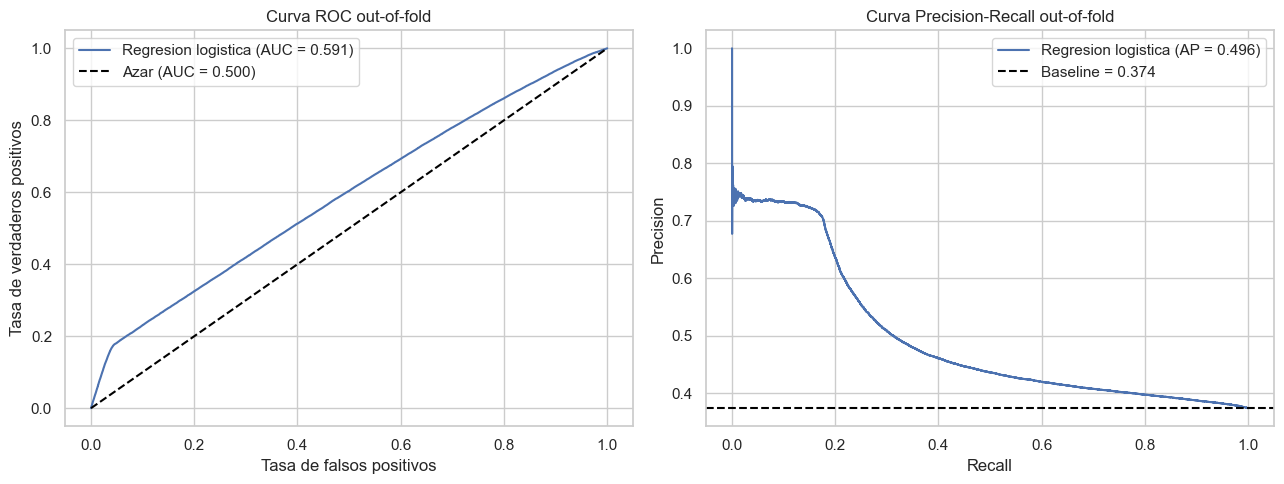

In [80]:
# Graficar curvas ROC y Precision-Recall con predicciones OOF
from sklearn.metrics import roc_curve, precision_recall_curve

fpr, tpr, cortes_roc = roc_curve(y_train, probabilidades_oof)
precision_curva, recall_curva, cortes_pr = precision_recall_curve(y_train, probabilidades_oof)

roc_auc_oof = roc_auc_score(y_train, probabilidades_oof)
pr_auc_oof = average_precision_score(y_train, probabilidades_oof)
prevalencia_train = y_train.mean()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(fpr, tpr, label=f"Regresion logistica (AUC = {roc_auc_oof:.3f})")
axes[0].plot([0, 1], [0, 1], linestyle="--", color="black", label="Azar (AUC = 0.500)")
axes[0].set_title("Curva ROC out-of-fold")
axes[0].set_xlabel("Tasa de falsos positivos")
axes[0].set_ylabel("Tasa de verdaderos positivos")
axes[0].legend()

axes[1].plot(recall_curva, precision_curva, label=f"Regresion logistica (AP = {pr_auc_oof:.3f})")
axes[1].axhline(prevalencia_train, linestyle="--", color="black", label=f"Baseline = {prevalencia_train:.3f}")
axes[1].set_title("Curva Precision-Recall out-of-fold")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].legend()

plt.tight_layout()
plt.show()

**Hallazgo de las curvas:** la curva ROC está por encima de la diagonal, pero no se aleja mucho: AUC `0.591`, por lo que la capacidad de ordenar aceptados sobre rechazados es todavía débil. En Precision–Recall, el modelo alcanza AP `0.496` frente a una línea base de `0.374`; existe mejora para encontrar aceptaciones, pero aún queda bastante espacio para mejorar.

Una curva visualmente superior no basta: para NBO también deben mantenerse una buena calibración y un buen desempeño en los clientes/ofertas priorizados.

**Lectura:** el promedio mide el desempeño esperado dentro de Train y la desviación muestra estabilidad entre grupos de clientes. ROC-AUC y PR-AUC evalúan ranking sin depender del threshold; precision, recall y F1 usan 0.5.

In [81]:
# Calcular matriz de confusion out-of-fold con threshold 0.5
matriz_oof = confusion_matrix(y_train, predicciones_oof)
matriz_oof_df = pd.DataFrame(
    matriz_oof,
    index=["real_rechaza", "real_acepta"],
    columns=["predice_rechaza", "predice_acepta"]
)
matriz_oof_df

,predice_rechaza,predice_acepta
real_rechaza,121629,5789
real_acepta,62713,13533


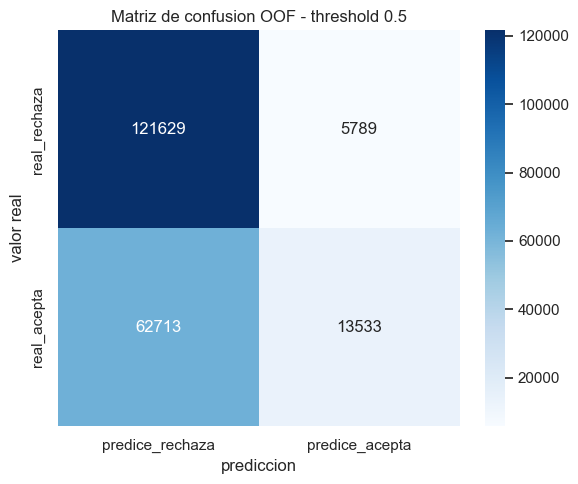

In [82]:
# Graficar matriz de confusion out-of-fold
plt.figure(figsize=(6, 5))
sns.heatmap(matriz_oof_df, annot=True, fmt="d", cmap="Blues")
plt.title("Matriz de confusion OOF - threshold 0.5")
plt.xlabel("prediccion")
plt.ylabel("valor real")
plt.tight_layout()
plt.show()

**Interpretacion:** esta matriz permite ver si el threshold 0.5 prioriza precision o recall. No se modifica todavía el punto de corte.

In [83]:
# Generar classification_report estandar para Train OOF
from sklearn.metrics import classification_report

reporte_clasificacion_train = pd.DataFrame(
    classification_report(
        y_train,
        predicciones_oof,
        target_names=["rechazada", "aceptada"],
        output_dict=True,
        zero_division=0
    )
).T

reporte_clasificacion_train.round(4)

              precision  recall  f1-score      support
rechazada        0.6598  0.9546    0.7803  127418.0000
aceptada         0.7004  0.1775    0.2832   76246.0000
accuracy         0.6637  0.6637    0.6637       0.6637
macro avg        0.6801  0.5660    0.5317  203664.0000
weighted avg     0.6750  0.6637    0.5942  203664.0000

**Reporte estándar de clasificación:** `classification_report` muestra precision, recall, F1 y support por clase, además de macro average y weighted average. La clase aceptada tiene precision `0.7004`, pero recall `0.1775`; la accuracy global oculta esta dificultad para recuperar aceptaciones.

In [84]:
# Preparar comparacion Train OOF vs Test final sin abrir Test
comparacion_train_test = pd.DataFrame({
    "metrica": [
        "roc_auc", "pr_auc", "accuracy", "precision",
        "recall", "f1", "log_loss", "brier_score"
    ],
    "train_oof": [
        roc_auc_score(y_train, probabilidades_oof),
        average_precision_score(y_train, probabilidades_oof),
        accuracy_score(y_train, predicciones_oof),
        precision_score(y_train, predicciones_oof, zero_division=0),
        recall_score(y_train, predicciones_oof, zero_division=0),
        f1_score(y_train, predicciones_oof, zero_division=0),
        log_loss(y_train, probabilidades_oof),
        brier_score_loss(y_train, probabilidades_oof)
    ],
    "test_final": [np.nan] * 8
})

comparacion_train_test.round(4)

        metrica  train_oof  test_final
0       roc_auc     0.5909         NaN
1        pr_auc     0.4960         NaN
2      accuracy     0.6637         NaN
3     precision     0.7004         NaN
4        recall     0.1775         NaN
5            f1     0.2832         NaN
6      log_loss     0.6362         NaN
7   brier_score     0.2222         NaN

**Comparación Train/Test:** la columna Test queda vacía intencionalmente. Cuando se cierre la selección del modelo, se ajustará una sola vez sobre todo Train y se completarán en Test estas mismas métricas, su `classification_report`, matriz de confusión, curvas ROC/PR y calibración. Hasta entonces, Test no se consulta.

In [83]:
# Construir tabla de calibracion con probabilidades out-of-fold
calibracion_oof = pd.DataFrame({
    "target": y_train.to_numpy(),
    "probabilidad": probabilidades_oof
})
calibracion_oof["decil"] = pd.qcut(calibracion_oof["probabilidad"], 10, duplicates="drop")

tabla_calibracion = calibracion_oof.groupby("decil", observed=False).agg(
    ofrecimientos=("target", "size"),
    probabilidad_promedio=("probabilidad", "mean"),
    aceptacion_observada=("target", "mean")
).reset_index(drop=True)
tabla_calibracion.round(4)

,ofrecimientos,probabilidad_promedio,aceptacion_observada
0,20367,0.2703,0.2784
1,20366,0.3092,0.3136
2,20366,0.3255,0.3339
3,20367,0.3368,0.3435
4,20366,0.3458,0.3495
5,20366,0.3539,0.3554
6,20367,0.3619,0.3633
7,20366,0.3708,0.3582
8,20366,0.3845,0.3652
9,20367,0.6856,0.6827


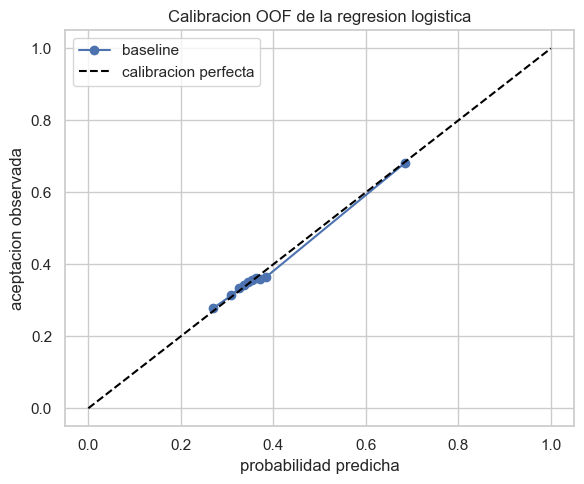

In [84]:
# Graficar calibracion de probabilidades out-of-fold
prob_observada, prob_predicha = calibration_curve(
    y_train, probabilidades_oof, n_bins=10, strategy="quantile"
)

plt.figure(figsize=(6, 5))
plt.plot(prob_predicha, prob_observada, marker="o", label="baseline")
plt.plot([0, 1], [0, 1], linestyle="--", color="black", label="calibracion perfecta")
plt.title("Calibracion OOF de la regresion logistica")
plt.xlabel("probabilidad predicha")
plt.ylabel("aceptacion observada")
plt.legend()
plt.tight_layout()
plt.show()

**Calibracion:** para un motor NBO importa que un score cercano a 0.70 represente aproximadamente 70% de aceptación observada. Brier score, log loss y esta curva permiten revisar esa propiedad, no solo la clasificación.

In [85]:
# Promediar coeficientes de la regresion entre folds
coeficientes_cv = pd.concat(coeficientes_folds, ignore_index=True)
resumen_coeficientes = coeficientes_cv.groupby("feature")["coeficiente"].agg(
    coeficiente_promedio="mean",
    desviacion_coeficiente="std",
    coeficiente_minimo="min",
    coeficiente_maximo="max"
).reset_index()
resumen_coeficientes["magnitud"] = resumen_coeficientes["coeficiente_promedio"].abs()
resumen_coeficientes["cambia_signo"] = (
    (resumen_coeficientes["coeficiente_minimo"] < 0) &
    (resumen_coeficientes["coeficiente_maximo"] > 0)
)

resumen_coeficientes.sort_values("magnitud", ascending=False).head(25).round(4)

,feature,coeficiente_promedio,desviacion_coeficiente,coeficiente_minimo,coeficiente_maximo,magnitud,cambia_signo
86,categoricas__oferta_id_OF020,0.2872,0.0123,0.2721,0.2991,0.2872,False
58,categoricas__oferta_es_mt_False,-0.2481,0.0053,-0.2520,-0.2390,0.2481,False
59,categoricas__oferta_es_mt_True,0.1969,0.0042,0.1906,0.2011,0.1969,False
117,categoricas__tipo_oferta_movistar_total,0.1969,0.0042,0.1906,0.2011,0.1969,False
136,numericas__dias_mora_prom,-0.1392,0.0072,-0.1492,-0.1307,0.1392,False
99,categoricas__plan_actual_id_OF009,-0.1270,0.0375,-0.1777,-0.0829,0.1270,False
131,numericas__ahorro_pct,0.1242,0.0039,0.1201,0.1290,0.1242,False
96,categoricas__plan_actual_id_OF006,0.1162,0.0229,0.0935,0.1536,0.1162,False
69,categoricas__oferta_id_OF003,-0.1128,0.0065,-0.1228,-0.1065,0.1128,False
57,categoricas__n_reclamos_3,-0.1086,0.0056,-0.1142,-0.1010,0.1086,False


In [86]:
# Revisar coeficientes extremos e inestables
diagnostico_coeficientes = pd.DataFrame({
    "coeficientes_codificados": [len(resumen_coeficientes)],
    "coeficientes_abs_mayor_5": [(resumen_coeficientes["magnitud"] > 5).sum()],
    "coeficientes_que_cambian_signo": [resumen_coeficientes["cambia_signo"].sum()],
    "coeficiente_maximo_absoluto": [resumen_coeficientes["magnitud"].max()]
})
diagnostico_coeficientes.round(4)

,coeficientes_codificados,coeficientes_abs_mayor_5,coeficientes_que_cambian_signo,coeficiente_maximo_absoluto
0,142,0,44,0.2872


In [87]:
# Agrupar magnitud de coeficientes por variable original
def variable_original(nombre):
    nombre_limpio = nombre.split("__", 1)[-1]
    for variable in sorted(columnas_X, key=len, reverse=True):
        if nombre_limpio == variable or nombre_limpio.startswith(variable + "_"):
            return variable
    return nombre_limpio

resumen_coeficientes["variable_original"] = resumen_coeficientes["feature"].map(variable_original)
aporte_por_variable = resumen_coeficientes.groupby("variable_original").agg(
    magnitud_media=("magnitud", "mean"),
    magnitud_maxima=("magnitud", "max"),
    categorias_codificadas=("feature", "count")
).sort_values("magnitud_maxima", ascending=False)

aporte_por_variable.round(4)

,magnitud_media,magnitud_maxima,categorias_codificadas
variable_original,,,
oferta_id,0.0511,0.2872,22
oferta_es_mt,0.2225,0.2481,2
tipo_oferta,0.0742,0.1969,6
dias_mora_prom,0.1392,0.1392,1
plan_actual_id,0.0379,0.1270,13
ahorro_pct,0.1242,0.1242,1
n_reclamos,0.0614,0.1086,4
meses_moroso,0.0340,0.0894,7
segmento_objetivo,0.0639,0.0842,3


**Precaucion con coeficientes:** magnitud pequeña no significa que una variable deba eliminarse. La interpretación está afectada por one-hot completo, regularización y redundancia entre atributos del cliente y de la oferta. Se usa como diagnóstico, no como selección definitiva.

In [88]:
# Revisar correlaciones altas entre predictoras numericas dentro de Train
corr_train = X_train[variables_numericas_modelo].astype(float).corr().abs()
triangulo_superior = np.triu(np.ones(corr_train.shape), k=1).astype(bool)
pares_correlacion = corr_train.where(triangulo_superior).stack().reset_index()
pares_correlacion.columns = ["variable_1", "variable_2", "correlacion_abs"]
pares_correlacion[pares_correlacion["correlacion_abs"] >= 0.80].sort_values(
    "correlacion_abs", ascending=False
).round(4)

,variable_1,variable_2,correlacion_abs
14,monto_facturado_prom,monto_facturado_prom_6m,0.9996


**Redundancia esperada:** además de correlaciones numéricas, `oferta_id`, `tipo_oferta`, precio, GB, ahorro y `oferta_es_mt` describen la misma oferta. Del lado cliente, elegibilidad resume varias condiciones de móvil, hogar, postpago y MT. La regularización L2 permite ejecutar el baseline, pero los coeficientes individuales deben leerse con cautela.

In [89]:
# Comparar contra un predictor nulo usando solo Train
probabilidades_nulas = np.zeros(len(y_train))

for indice_entrenamiento, indice_validacion in group_kfold.split(
    X_train, y_train, groups=grupos_train
):
    probabilidades_nulas[indice_validacion] = y_train.iloc[indice_entrenamiento].mean()

predicciones_nulas = (probabilidades_nulas >= 0.5).astype(int)

comparacion_baseline = pd.DataFrame({
    "modelo": ["predictor_nulo", "regresion_logistica"],
    "roc_auc": [roc_auc_score(y_train, probabilidades_nulas), resumen_metricas.loc["roc_auc", "promedio"]],
    "pr_auc": [average_precision_score(y_train, probabilidades_nulas), resumen_metricas.loc["pr_auc", "promedio"]],
    "accuracy": [accuracy_score(y_train, predicciones_nulas), resumen_metricas.loc["accuracy", "promedio"]],
    "log_loss": [log_loss(y_train, probabilidades_nulas), resumen_metricas.loc["log_loss", "promedio"]],
    "brier_score": [brier_score_loss(y_train, probabilidades_nulas), resumen_metricas.loc["brier_score", "promedio"]]
})
comparacion_baseline.round(4)

,modelo,roc_auc,pr_auc,accuracy,log_loss,brier_score
0,predictor_nulo,0.4972,0.373,0.6256,0.6612,0.2342
1,regresion_logistica,0.5909,0.496,0.6637,0.6362,0.2222


**Valor incremental dentro de Train:** la regresión supera al predictor nulo en ranking, accuracy, log loss y Brier score. La mejora es real, aunque todavía moderada; no justifica afirmar que el problema esté resuelto.

## 17. Conclusion del baseline

- El baseline es mejor que no modelar, pero su poder de discriminación sigue siendo bajo: ROC-AUC promedio `0.5909` y PR-AUC `0.4960`, frente a `0.3730` del predictor nulo.
- Es muy estable entre folds: la desviación de ROC-AUC es `0.0004` y la de PR-AUC `0.0040`. El resultado no depende de un grupo particular de clientes.
- Con threshold 0.5 obtiene precision alta (`0.7004`) pero recall muy bajo (`0.1775`). Solo identifica 13,533 de 76,246 aceptaciones out-of-fold; deja 62,713 falsos negativos. El threshold no se modifica todavía.
- La calibración es razonablemente buena: Brier `0.2222` y log loss `0.6362`, mejores que `0.2342` y `0.6612` del predictor nulo. En el decil superior predice `68.56%` y se observa `68.27%`.
- No aparecen coeficientes extremos: el máximo absoluto es `0.2872`. Sin embargo, 44 coeficientes pequeños cambian de signo entre folds, señal de baja información o redundancia.
- Las señales más consistentes son identidad/tipo de oferta, MT, mora, ahorro, reclamos y antigüedad. Canal, voz, SMS, uso de app, facturación y ubicación muestran coeficientes pequeños en este baseline.
- Hay multicolinealidad clara: `monto_facturado_prom` y `monto_facturado_prom_6m` correlacionan `0.9996`. También existe redundancia entre `oferta_id`, tipo, precio, GB, ahorro y flag MT, y entre elegibilidad y condiciones del cliente.
- Algunos signos no deben interpretarse causalmente: precio y ahorro aparecen positivos principalmente porque identifican ofertas MT, históricamente seleccionadas para elegibles y con mayor aceptación.

Para Next Best Offer conviene priorizar **PR-AUC para ranking de aceptaciones**, acompañado por **Brier score, log loss y calibración** porque las probabilidades se compararán entre ofertas. Accuracy no debe ser la métrica principal. En una etapa de negocio también se deberá medir lift o conversión en el top-k y valor esperado.

Antes de probar modelos complejos, lo siguiente es diagnosticar la redundancia mediante comparaciones dentro de Train, incorporar solo interacciones cliente-oferta justificadas, revisar el posible leakage temporal y evaluar si las probabilidades mantienen calibración por tipo de oferta. Test continúa cerrado; no se realiza feature selection definitiva, tuning ni optimización del threshold.

## 18. Comparacion de modelos dentro de Train

Se comparan modelos usando los mismos cinco folds de `GroupKFold` y el mismo Train. Test permanece reservado. Para mantener una búsqueda moderada se evaluaron la logística inicial, dos variantes logísticas con menor redundancia e interacciones, y dos configuraciones de XGBoost. Random Forest se omitió por tiempo de cómputo después de comprobar que el boosting no mejoraba la logística.

In [ ]:
# Crear interacciones justificadas y retirar la variable numerica redundante
X_train_comparacion = X_train.copy()
X_train_comparacion["antiguedad_tramo"] = pd.cut(
    X_train_comparacion["antiguedad_meses"],
    [-np.inf, 60, 120, np.inf],
    labels=["hasta_60", "61_a_120", "mas_120"]
).astype(str)
X_train_comparacion["tiene_reclamos"] = X_train_comparacion["n_reclamos"].astype(float) > 0
X_train_comparacion["tiene_mora"] = X_train_comparacion["meses_moroso"].astype(float) > 0
X_train_comparacion["antiguedad_x_oferta"] = X_train_comparacion["antiguedad_tramo"] + "__" + X_train_comparacion["tipo_oferta"]
X_train_comparacion["reclamos_x_oferta"] = X_train_comparacion["tiene_reclamos"].astype(str) + "__" + X_train_comparacion["tipo_oferta"]
X_train_comparacion["mora_x_oferta"] = X_train_comparacion["tiene_mora"].astype(str) + "__" + X_train_comparacion["tipo_oferta"]
X_train_comparacion["elegibilidad_x_mt"] = X_train_comparacion["elegible_mt"] + "__" + X_train_comparacion["oferta_es_mt"]

numericas_reducidas = [col for col in variables_numericas_modelo if col != "monto_facturado_prom_6m"]
interacciones_categoricas = [
    "antiguedad_tramo", "tiene_reclamos", "tiene_mora",
    "antiguedad_x_oferta", "reclamos_x_oferta",
    "mora_x_oferta", "elegibilidad_x_mt"
]
categoricas_interacciones = variables_categoricas_modelo + interacciones_categoricas

**Features probadas:** se retiró `monto_facturado_prom_6m` por correlación 0.9996 con facturación actual. Se probaron interacciones de antigüedad, reclamos, mora y elegibilidad con oferta. La eliminación o interacción solo se conservaría si aumentaba PR-AUC agrupado.

In [ ]:
# Funcion de evaluacion agrupada usada para cada candidato
def evaluar_candidato(nombre, pipeline, X_candidato):
    probabilidades = np.zeros(len(X_candidato))
    metricas = []
    modelos = []
    for fold, (idx_fit, idx_validacion) in enumerate(
        group_kfold.split(X_candidato, y_train, groups=grupos_train), start=1
    ):
        candidato = clone(pipeline)
        candidato.fit(X_candidato.iloc[idx_fit], y_train.iloc[idx_fit])
        prob_validacion = candidato.predict_proba(X_candidato.iloc[idx_validacion])[:, 1]
        prob_fit = candidato.predict_proba(X_candidato.iloc[idx_fit])[:, 1]
        prediccion = (prob_validacion >= 0.5).astype(int)
        probabilidades[idx_validacion] = prob_validacion
        metricas.append({
            "fold": fold,
            "pr_auc": average_precision_score(y_train.iloc[idx_validacion], prob_validacion),
            "roc_auc": roc_auc_score(y_train.iloc[idx_validacion], prob_validacion),
            "brier": brier_score_loss(y_train.iloc[idx_validacion], prob_validacion),
            "log_loss": log_loss(y_train.iloc[idx_validacion], prob_validacion),
            "precision": precision_score(y_train.iloc[idx_validacion], prediccion, zero_division=0),
            "recall": recall_score(y_train.iloc[idx_validacion], prediccion, zero_division=0),
            "f1": f1_score(y_train.iloc[idx_validacion], prediccion, zero_division=0),
            "train_pr_auc": average_precision_score(y_train.iloc[idx_fit], prob_fit)
        })
        modelos.append(candidato)
    return pd.DataFrame(metricas), probabilidades, modelos

In [ ]:
# Evaluar solamente configuraciones moderadas dentro de Train
from xgboost import XGBClassifier

# Logistica ajustada: mismas transformaciones dentro del Pipeline y C=0.1
preprocessing_logistica_reducida = ColumnTransformer([
    ("numericas", pipeline_numerico, numericas_reducidas),
    ("categoricas", pipeline_categorico, categoricas_interacciones)
])
logistica_ajustada = Pipeline([
    ("preprocessing", preprocessing_logistica_reducida),
    ("modelo", LogisticRegression(C=0.1, max_iter=1000, random_state=42))
])

# XGBoost baseline y alternativa regularizada de profundidad 3
preprocessing_xgb = ColumnTransformer([
    ("numericas", SimpleImputer(strategy="median"), numericas_reducidas),
    ("categoricas", pipeline_categorico, variables_categoricas_modelo)
])
xgb_baseline = Pipeline([
    ("preprocessing", preprocessing_xgb),
    ("modelo", XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8, eval_metric="logloss",
        tree_method="hist", random_state=42, n_jobs=-1))
])
xgb_ajustado = Pipeline([
    ("preprocessing", preprocessing_xgb),
    ("modelo", XGBClassifier(n_estimators=400, max_depth=3, learning_rate=0.05,
        min_child_weight=5, subsample=0.8, colsample_bytree=0.8,
        eval_metric="logloss", tree_method="hist", random_state=42, n_jobs=-1))
])

# Cada llamada usa los mismos folds y nunca consulta Test.
metricas_logistica_ajustada, prob_logistica_ajustada, modelos_logistica = evaluar_candidato(
    "logistica_ajustada", logistica_ajustada,
    X_train_comparacion[numericas_reducidas + categoricas_interacciones]
)
metricas_xgb_baseline, prob_xgb_baseline, modelos_xgb_baseline = evaluar_candidato(
    "xgb_baseline", xgb_baseline,
    X_train_comparacion[numericas_reducidas + variables_categoricas_modelo]
)
metricas_xgb_ajustado, prob_xgb_ajustado, modelos_xgb_ajustado = evaluar_candidato(
    "xgb_ajustado", xgb_ajustado,
    X_train_comparacion[numericas_reducidas + variables_categoricas_modelo]
)

In [ ]:
# Comparar todas las configuraciones con el baseline inicial
comparacion_candidatos

                              modelo  pr_auc  pr_std  roc_auc  roc_std   brier  log_loss  precision  recall      f1  brecha_overfit_pr
0                  logistica_inicial  0.49600 0.00399  0.59090  0.00041 0.22219   0.63623    0.70044 0.17746 0.28314             0.00416
1  logistica_reducida_interacciones_C1 0.49543 0.00346  0.59055  0.00082 0.22218   0.63621    0.70072 0.17733 0.28300             0.00527
2 logistica_reducida_interacciones_C0.1 0.49544 0.00351  0.59059  0.00082 0.22218   0.63620    0.70072 0.17733 0.28300             0.00527
3                    xgboost_baseline  0.49302 0.00502  0.58778  0.00220 0.22229   0.63648    0.70649 0.17500 0.28047             0.04763
4                      xgboost_depth3  0.49377 0.00414  0.58856  0.00151 0.22221   0.63629    0.70625 0.17502 0.28049             0.03055

**Resultado de optimización:** ni retirar la variable redundante, ni añadir interacciones, ni cambiar `C` mejoró PR-AUC. La logística inicial conserva `0.4960` frente a `0.4954` de la ajustada. XGBoost mejora al regularizar profundidad, pero llega solo a `0.4938` y presenta una brecha Train–validación mayor.

In [ ]:
# Tabla final por familia de modelos
comparacion_final_modelos

               modelo          version_baseline       version_optimizada          version_elegida  pr_auc  roc_auc   brier  log_loss  estabilidad_pr  calibracion_mae                         observaciones
0 Regresion logistica          inicial C=1.0  reducida+interacciones C=0.1          inicial C=1.0 0.49600  0.59090 0.22219   0.63623         0.00399          0.00690  La optimizacion no mejoro PR-AUC
1             XGBoost profundidad=4, 300 arboles profundidad=3, 400 arboles profundidad=3, 400 arboles 0.49377  0.58856 0.22221   0.63629         0.00414          0.00746  Menor PR-AUC y mayor overfitting

In [ ]:
# Comparar lift y aceptacion observada en los scores mas altos
metricas_ranking_modelos

                              modelo  aceptacion_top10  lift_top10  aceptacion_top20  lift_top20
0                  logistica_inicial             0.6827      1.8235             0.5239      1.3995
1 logistica_reducida_interacciones_C0.1             0.6837      1.8263             0.5235      1.3982
2                    xgboost_baseline             0.6814      1.8202             0.5226      1.3959
3                      xgboost_depth3             0.6821      1.8221             0.5226      1.3959

**Valor para ranking:** el 10% con mayor score de la logística inicial alcanza 68.27% de aceptación, 1.82 veces la tasa promedio de Train. En el top 20% alcanza 52.39%, con lift 1.40. XGBoost no mejora estos resultados.

In [ ]:
# Revisar calibracion MT vs no MT de los modelos elegidos
calibracion_mt_modelos

               modelo  oferta_es_mt      n  probabilidad_media  aceptacion_observada  brecha_abs
0 Regresion logistica         False 184337              0.34025               0.34019     0.00005
1 Regresion logistica          True  19327              0.70046               0.70037     0.00010
2             XGBoost         False 184337              0.34033               0.34019     0.00014
3             XGBoost          True  19327              0.69977               0.70037     0.00060

**Calibración por oferta:** ambos modelos reproducen bien la tasa agregada MT/no-MT, pero esto refleja en gran parte la fuerte separación histórica entre ambas familias. La logística tiene menor error promedio de calibración por deciles (`0.0069` vs `0.0075`).

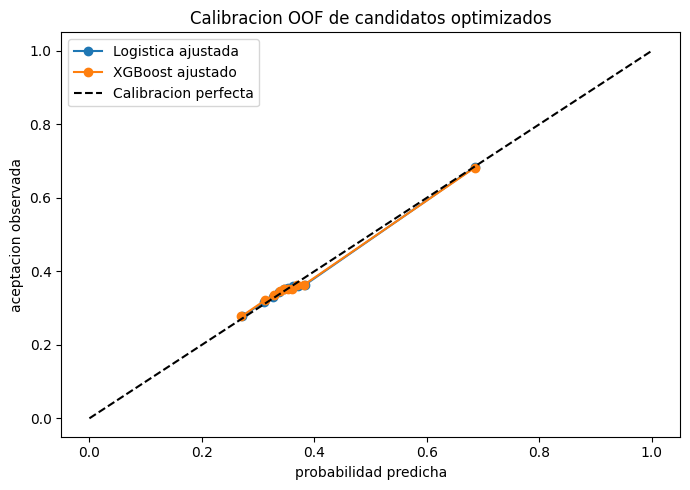

In [ ]:
# Graficar calibracion de los candidatos optimizados
prob_observada_log, prob_predicha_log = calibration_curve(
    y_train, prob_logistica_ajustada, n_bins=10, strategy="quantile"
)
prob_observada_xgb, prob_predicha_xgb = calibration_curve(
    y_train, prob_xgb_ajustado, n_bins=10, strategy="quantile"
)
plt.figure(figsize=(7, 5))
plt.plot(prob_predicha_log, prob_observada_log, marker="o", label="Logistica ajustada")
plt.plot(prob_predicha_xgb, prob_observada_xgb, marker="o", label="XGBoost ajustado")
plt.plot([0, 1], [0, 1], linestyle="--", color="black", label="Calibracion perfecta")
plt.title("Calibracion OOF de candidatos optimizados")
plt.xlabel("probabilidad predicha")
plt.ylabel("aceptacion observada")
plt.legend()
plt.tight_layout()
plt.show()

### Features e interacciones

- En logística ajustada aparecen `antiguedad_x_oferta`, `reclamos_x_oferta`, `mora_x_oferta` y `elegibilidad_x_mt` entre los coeficientes visibles, especialmente para MT.
- Sin embargo, agregar estas interacciones reduce PR-AUC de `0.4960` a `0.4954`. Por tanto, no se conservan en la regresión logística final candidata.
- En XGBoost dominan `ahorro_pct`, `tipo_oferta=movistar_total` y `oferta_es_mt`; después aparecen mora, reclamos y antigüedad con importancia mucho menor.
- Esto confirma que el modelo aprende principalmente la separación histórica MT/no-MT y encuentra poca señal adicional de hiperpersonalización.

## 19. Modelo recomendado antes de Test

**Ganador:** regresión logística inicial.

- PR-AUC `0.4960`, superior a `0.4938` de XGBoost ajustado.
- Mejor estabilidad y menor brecha Train–validación (`0.0042` vs `0.0306`).
- Calibración ligeramente mejor.
- Lift top-10 prácticamente igual o superior.
- Mayor simplicidad, velocidad y explicabilidad para el asesor.

La mejora de XGBoost es negativa: no justifica complejidad adicional. No hay señales importantes de overfitting en logística; XGBoost sí muestra una brecha mayor, aunque moderada. Random Forest no se ejecuta porque XGBoost ya representa el modelo no lineal solicitado y no logró superar la regresión.

La regresión logística inicial es la candidata que debe llevarse posteriormente a Test. Antes de abrir Test conviene revisar la calibración dentro de cada oferta específica y documentar el riesgo de leakage temporal. Test continúa completamente reservado.